**Importing Packages**

In [7]:
# ------------------------------------------------------------------------------
# Setup and Environment Configuration
# ------------------------------------------------------------------------------

import os
import time
import absl.logging
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from keras.initializers import Constant
from keras.utils import plot_model
from sklearn.model_selection import train_test_split

absl.logging.set_verbosity(absl.logging.INFO)

# Disable oneDNN optimizations for reproducibility/debugging
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ------------------------------------------------------------------------------
# Configure GPU Memory Limit
# ------------------------------------------------------------------------------

gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=15000)]
        )
    except RuntimeError as e:
        print("GPU Configuration Error:", e)

# ------------------------------------------------------------------------------
# Keras Model Building Imports
# ------------------------------------------------------------------------------

from keras.models import Sequential, Model
from keras import Input, layers, optimizers, regularizers
from keras.layers import (
    Dense, Dropout, Flatten, Reshape, Lambda,
    BatchNormalization, LayerNormalization, GlobalAveragePooling1D,
    Conv2D, Conv2DTranspose, MaxPooling2D,
    GRU, LSTM, Add, Concatenate, 
    LeakyReLU, ELU, PReLU, MultiHeadAttention
)

%autosave 180


Autosaving every 180 seconds


In [8]:
from plotting_utils import plot_training_history, set_clean_style
import matplotlib.pyplot as plt
from keras.utils import plot_model


**Functions for Rotational & Flip Invariance AND Canonicalization**

In [9]:
from symmetry_utils import RotFlipInvariants, findCanonicalForm, generate_augmented_versions

**Pruned Dataset Processing**

Loading PMF from dataset

#### Removing data associated with either polymer index 0 or surface index 0

In [10]:
pmf_temp = np.load("data_final/target/pmf_surface.npy")
print(pmf_temp.shape)

# pmf_data = pmf_temp
pmf_data = pmf_temp[1:, 1:]

print(pmf_data.shape)

(92, 92, 100)
(91, 91, 100)


Loading polymer sequences from dataset

In [11]:
polymer_temp = np.load("data_final/feature/polymer.npy")
print(polymer_temp.shape)

# polymer_data = np.tile(polymer_temp[:][np.newaxis,:,:],(92,1,1))
polymer_data = np.tile(polymer_temp[1:][np.newaxis, :, :], (91, 1, 1))

print(polymer_data.shape)

(92, 40)
(91, 91, 40)


Loading surface sequences from dataset

In [12]:
surface_temp = np.load("data_final/feature/surface.npy")
print(surface_temp.shape)

# surface_data = np.tile(surface_temp[:,np.newaxis,:,:],(1,92,1,1))
surface_data = np.tile(surface_temp[1:, np.newaxis, :, :], (1, 91, 1, 1))

print(surface_data.shape)

(92, 20, 20)
(91, 91, 20, 20)


Reshaping dataset

In [13]:

reshaped_pmf = pmf_data.reshape(91 * 91, 100)
reshaped_polymer = polymer_data.reshape(91 * 91, 40)
reshaped_surface = surface_data.reshape(91 * 91, 20, 20)

print(f"Reshaped Dataset:")
print(
    f"Surface shape: {reshaped_surface.shape}\nPolymer shape: {reshaped_polymer.shape}\nPMF shape: {reshaped_pmf.shape}"
)

Reshaped Dataset:
Surface shape: (8281, 20, 20)
Polymer shape: (8281, 40)
PMF shape: (8281, 100)


Implementing Symmetry and Canonicalization measures

In [14]:
surfacetemp = []
polymertemp = []
pmftemp = []

for i in range(len(reshaped_pmf)):
    xsample = reshaped_surface[i, :, :]
    ysample = reshaped_polymer[i, :]
    zsample = reshaped_pmf[i, :]
    xsample = RotFlipInvariants(
        xsample, rot=True, flip=True
    )  # introduce rotation and flip invariants of surface
    xsample = findCanonicalForm(
        xsample
    )  # use canonical form of surface if model_type is 1
    ysample = np.tile(ysample, (len(xsample), 1))
    zsample = np.tile(zsample, (len(xsample), 1))
    surfacetemp.extend(xsample)
    polymertemp.extend(ysample)
    pmftemp.extend(zsample)

surfacetemp = np.array(surfacetemp)
polymertemp = np.array(polymertemp)
pmftemp = np.array(pmftemp)

print(surfacetemp.shape)
print(polymertemp.shape)
print(pmftemp.shape)

crude_surface = []
crude_polymer = []
crude_pmf = []

for i in range(len(pmftemp)):
    xsample = surfacetemp[i, :, :]
    ysample = polymertemp[i, :]
    zsample = pmftemp[i, :]
    ysample = RotFlipInvariants(
        ysample, rot=True, flip=True
    )  # introduce invert invariant of polymer
    ysample = findCanonicalForm(
        ysample
    )  # use canonical form of polymer if model_type is 1
    xsample = np.tile(xsample, (len(ysample), 1, 1))
    zsample = np.tile(zsample, (len(ysample), 1))
    crude_surface.extend(xsample)
    crude_polymer.extend(ysample)
    crude_pmf.extend(zsample)

crude_surface = np.array(crude_surface)
crude_polymer = np.array(crude_polymer)
crude_pmf = np.array(crude_pmf)

print(crude_surface.shape)
print(crude_polymer.shape)
print(crude_pmf.shape)

(8281, 20, 20)
(8281, 40)
(8281, 100)
(8281, 20, 20)
(8281, 40)
(8281, 100)


Modifying shape of input and output

In [15]:
ydata = crude_pmf
xdata = np.hstack((crude_surface.reshape(len(crude_pmf), 20 * 20), crude_polymer))

print(xdata.shape)
print(ydata.shape)

(8281, 440)
(8281, 100)


In [16]:
##########################################################################################################
####Calculating Different regions of PMF##################################################################
####1. Delta F 2. Positive gradient and negative gradient 3. Positive and negative second derivative######
##########################################################################################################
# plateau_region = np.where(np.abs(np.diff(pmf_data[0,0,:])) < threshold)[0]
window_size = 3  # Window size to decide the region of PMF profile to scan.
prev_std = float("inf")  # Initializing std
delF = np.zeros((91, 91))
positive_gradient = np.zeros(
    (91, 91)
)  # Positive gradient, will capture PMF transition curves
negative_gradient = np.zeros(
    (91, 91)
)  # Negative gradient wll capture the curve before minima.
positive_curvature = np.zeros(
    (91, 91)
)  # Positive second derivative, will capture the curvature at the positive gradient
negative_curvature = np.zeros(
    (91, 91)
)  # Negative second derivative, will capture the curvature at the curvature before the minima
wm_positive_curvature = np.zeros(
    (91, 91)
)  # Weighted mean, to capture the steepest region of the curvature
wm_negative_curvature = np.zeros((91, 91))  # Weighted mean
min_pmf = np.zeros((91, 91))
min_index = np.zeros((91, 91))
min_index_value = np.zeros((91, 91))
for i in range(91):
    for j in range(91):
        min_pmf[i, j] = np.min(pmf_data[i, j, :])
        min_index[i, j] = np.argmin(pmf_data[i, j, :])
        min_index_value[i, j] = 4.7 + 0.1 * min_index[i, j]
        for start in range(len(pmf_data[i, j, :]) - window_size):
            window = pmf_data[i, j, start : start + window_size]
            current_std = np.std(window)
            tol = 0.1 * np.mean(
                window
            )  # Tolerance for accepting the region to capture flat region
            if np.abs(current_std - prev_std) < tol:
                plat = (start, start + window_size)
            else:
                plat = None

            prev_std = current_std
        if plat is not None:

            for k in range(plat[0], plat[1]):
                pmf_plat = pmf_data[i, j, k]
            pmf_max = np.mean(pmf_plat)
            #             print(pmf_max)
            delF[i, j] = pmf_max - np.min(
                pmf_data[i, j, :]
            )  # Calculating Plateu region of th profile
            gradients = np.gradient(pmf_data[i, j, :])  # 1st derivative
            second_derivative = np.gradient(gradients)  # 2nd derivative
            positive_id = gradients > 0
            negative_id = gradients < 0
            pos_w = np.abs(gradients[positive_id])  # Weight taken to be gradient values
            neg_w = np.abs(gradients[negative_id])
            positive_gradient[i, j] = np.mean(gradients[positive_id])
            negative_gradient[i, j] = np.mean(gradients[negative_id])
            positive_curvature[i, j] = np.mean(second_derivative[positive_id])
            negative_curvature[i, j] = np.mean(second_derivative[negative_id])
            wm_positive_curvature[i, j] = np.sum(
                second_derivative[positive_id] * pos_w
            ) / np.sum(pos_w)
            wm_negative_curvature[i, j] = np.sum(
                second_derivative[negative_id] * neg_w
            ) / np.sum(neg_w)
            # print(f"Delta_F for s{91}p{91},{del_F}")
#     print(prev_std)

print(delF.shape)

(91, 91)


Building canonical datasets

In [17]:
# Assigning canonical datasets
canonical_default_xdata = np.array(xdata.copy())
canonical_default_ydata = np.array(ydata.copy())

# Constructing bcext_xdata and bcext_ydata
# delF = np.mean(ydata[:, 90:], axis=1) - np.min(ydata, axis=1)

canonical_backext_xdata = np.zeros((len(ydata), 41))
canonical_backext_xdata[:, 0] = delF.reshape(91 * 91)
canonical_backext_xdata[:, 1:] = xdata[:, 400:]
canonical_backext_ydata = ydata  # Already defined

print(canonical_default_xdata.shape)
print(canonical_default_ydata.shape)
print(canonical_backext_xdata.shape)
print(canonical_backext_ydata.shape)

(8281, 440)
(8281, 100)
(8281, 41)
(8281, 100)


In [953]:
augmented_default_xdata, augmented_default_ydata = generate_augmented_versions(
    canonical_default_xdata, canonical_default_ydata
)  # (N, k1, 440); (N, k2, 100)

augmented_backext_xdata = []
for ind1 in range(len(augmented_default_ydata)):
    bcx_temp = []
    for ind2 in range(len(augmented_default_ydata[ind1])):
        delF_temp = [np.mean(augmented_default_ydata[ind1][ind2][90:])
                   - np.min(augmented_default_ydata[ind1][ind2])]
        bcx_temp.append(np.concatenate([delF_temp, augmented_default_xdata[ind1][ind2][400:]]))
    augmented_backext_xdata.append(bcx_temp)

augmented_backext_ydata = augmented_default_ydata  # Already defined


Randomization of subsets (by means of randomizing indices)

In [942]:
random_state = 11
np.random.seed(random_state)

num_canonical = len(canonical_default_xdata)

indices = np.random.permutation(num_canonical)
print(indices)
test_size = int(0.1 * num_canonical)
valid_size = int(0.2 * num_canonical)
train_size = num_canonical - (
    test_size + valid_size
)  # redundant just for ease of explanation

test_indices = indices[:test_size]
valid_indices = indices[test_size : test_size + valid_size]
train_indices = indices[test_size + valid_size :]

[6420 2656 1069 ... 7259 5200 3775]


Dataset segmentation

In [943]:
# Ca nonical dataset segmentation
canonical_default_train_x = canonical_default_xdata[train_indices]
canonical_default_train_y = canonical_default_ydata[train_indices]

canonical_default_valid_x = canonical_default_xdata[valid_indices]
canonical_default_valid_y = canonical_default_ydata[valid_indices]

canonical_default_test_x = canonical_default_xdata[test_indices]
canonical_default_test_y = canonical_default_ydata[test_indices]

# Augmented dataset segmentation
# Combine all (m,k1*k2, 440) arrays into a single (m * k1 * k2, 440) array
 
augmented_default_train_y = np.concatenate(
    [augmented_default_ydata[i] for i in train_indices], axis=0)

augmented_default_valid_x = np.concatenate(
    [augmented_default_xdata[i] for i in valid_indices], axis=0)
augmented_default_valid_y = np.concatenate(
    [augmented_default_ydata[i] for i in valid_indices], axis=0)

augmented_default_test_x = np.concatenate(
    [augmented_default_xdata[i] for i in test_indices], axis=0)
augmented_default_test_y = np.concatenate(
    [augmented_default_ydata[i] for i in test_indices], axis=0)

#####################################################################################################################
## Backext dataset

# Canonical dataset segmentation
canonical_backext_train_x = canonical_backext_xdata[train_indices]
canonical_backext_train_y = canonical_backext_ydata[train_indices]

canonical_backext_valid_x = canonical_backext_xdata[valid_indices]
canonical_backext_valid_y = canonical_backext_ydata[valid_indices]

canonical_backext_test_x = canonical_backext_xdata[test_indices]
canonical_backext_test_y = canonical_backext_ydata[test_indices]

# Augmented dataset segmentation
# Combine all (m,k1*k2, 440) arrays into a single (m * k1 * k2, 440) array
augmented_backext_train_x = np.concatenate(
    [augmented_backext_xdata[i] for i in train_indices], axis=0)
augmented_backext_train_y = np.concatenate(
    [augmented_backext_ydata[i] for i in train_indices], axis=0)

augmented_backext_valid_x = np.concatenate(
    [augmented_backext_xdata[i] for i in valid_indices], axis=0)
augmented_backext_valid_y = np.concatenate(
    [augmented_backext_ydata[i] for i in valid_indices], axis=0)

augmented_backext_test_x = np.concatenate(
    [augmented_backext_xdata[i] for i in test_indices], axis=0)
augmented_backext_test_y = np.concatenate(
    [augmented_backext_ydata[i] for i in test_indices], axis=0)

In [944]:
print("Canonical datasets:")
print(canonical_default_train_x.shape)
print(canonical_default_valid_x.shape)
print(canonical_default_test_x.shape)
print(canonical_backext_train_x.shape)
print(canonical_backext_valid_x.shape)
print(canonical_backext_test_x.shape)

print("Augmented datasets:")
print(augmented_default_train_x.shape)
print(augmented_default_valid_x.shape)
print(augmented_default_test_x.shape)
print(augmented_backext_train_x.shape)
print(augmented_backext_valid_x.shape)
print(augmented_backext_test_x.shape)

Canonical datasets:
(5797, 440)
(1656, 440)
(828, 440)
(5797, 41)
(1656, 41)
(828, 41)
Augmented datasets:
(90831, 440)
(25907, 440)
(13042, 440)
(90831, 41)
(25907, 41)
(13042, 41)


Choose the model type

In [22]:
neural_tag = "canonical"  # three choices: "augmented", "canonical", "mixed"

if neural_tag == "canonical":
    # completely canonical
    fdX_train, fdX_test, fdX_valid = (
        canonical_default_train_x,
        canonical_default_test_x,
        canonical_default_valid_x,
    )
    fdY_train, fdY_test, fdY_valid = (
        canonical_default_train_y,
        canonical_default_test_y,
        canonical_default_valid_y,
    )
    tdX_train, tdX_test, tdX_valid = (
        canonical_default_train_x,
        canonical_default_test_x,
        canonical_default_valid_x,
    )
    tdY_train, tdY_test, tdY_valid = (
        canonical_default_train_y,
        canonical_default_test_y,
        canonical_default_valid_y,
    )
    bxX_train, bxX_test, bxX_valid = (
        canonical_backext_train_x,
        canonical_backext_test_x,
        canonical_backext_valid_x,
    )
    bxY_train, bxY_test, bxY_valid = (
        canonical_backext_train_y,
        canonical_backext_test_y,
        canonical_backext_valid_y,
    )
elif neural_tag == "augmented":
    # completely augmented
    fdX_train, fdX_test, fdX_valid = (
        augmented_default_train_x,
        augmented_default_test_x,
        augmented_default_valid_x,
    )
    fdY_train, fdY_test, fdY_valid = (
        augmented_default_train_y,
        augmented_default_test_y,
        augmented_default_valid_y,
    )
    tdX_train, tdX_test, tdX_valid = (
        augmented_default_train_x,
        augmented_default_test_x,
        augmented_default_valid_x,
    )
    tdY_train, tdY_test, tdY_valid = (
        augmented_default_train_y,
        augmented_default_test_y,
        augmented_default_valid_y,
    )
    bxX_train, bxX_test, bxX_valid = (
        augmented_backext_train_x,
        augmented_backext_test_x,
        augmented_backext_valid_x,
    )
    bxY_train, bxY_test, bxY_valid = (
        augmented_backext_train_y,
        augmented_backext_test_y,
        augmented_backext_valid_y,
    )
elif neural_tag == "mixed":
    # mix of canonical and augmented datasets for different training sections
    fdX_train, fdX_test, fdX_valid = (
        augmented_default_train_x,
        augmented_default_test_x,
        augmented_default_valid_x,
    )
    fdY_train, fdY_test, fdY_valid = (
        augmented_default_train_y,
        augmented_default_test_y,
        augmented_default_valid_y,
    )
    tdX_train, tdX_test, tdX_valid = (
        canonical_default_train_x,
        canonical_default_test_x,
        canonical_default_valid_x,
    )
    tdY_train, tdY_test, tdY_valid = (
        canonical_default_train_y,
        canonical_default_test_y,
        canonical_default_valid_y,
    )
    bxX_train, bxX_test, bxX_valid = (
        canonical_backext_train_x,
        canonical_backext_test_x,
        canonical_backext_valid_x,
    )
    bxY_train, bxY_test, bxY_valid = (
        canonical_backext_train_y,
        canonical_backext_test_y,
        canonical_backext_valid_y,
    )
else:
    raise Exception("Invalid neural_tag!!!")

Custom Callbacks and Loss Functions

In [23]:
class CustomCallback(tf.keras.callbacks.Callback):
    loss_metric = ""
    val = 0.0

    def __init__(self, loss_metric, val):
        self.loss_metric = loss_metric
        self.val = val

    def on_epoch_end(self, epoch, logs=None):
        if logs.get(self.loss_metric) <= self.val:
            self.model.stop_training = True  # Early stopping callbacks


# Alternative
# early_stop = EarlyStopping(monitor="loss", patience=3, min_delta=0.05, restore_best_weights=True)

In [24]:
from timeit import default_timer as timer

class LogsCallback(tf.keras.callbacks.Callback):
    def __init__(self, skip_epochs, monitor=["val_mae", "val_mse"]):
        """
        Args:
            skip_epochs: Print stats every this many epochs
            monitor: List of metrics to monitor (e.g., ["val_mae", "val_mse"])
                     If None, will print all available metrics in logs
        """
        super().__init__()
        self.skip_epochs = skip_epochs
        self.epoch = 0
        self.start_time = 0.0
        self.time_block_duration = "0 sec"
        self.monitor = monitor if monitor is not None else []

    def on_train_begin(self, logs=None):
        self.start_time = timer()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.skip_epochs == 0:
            # Calculate time duration
            current_time = timer()
            elapsed_sec = int((current_time - self.start_time) % 60)
            elapsed_min = int((current_time - self.start_time) / 60.0)
            self.time_block_duration = f"{elapsed_min}min {elapsed_sec}sec"
            
            # Prepare output string
            output_parts = [f"Epoch: {epoch}"]
            
            # Add all monitored metrics or all available metrics if none specified
            metrics_to_show = self.monitor if self.monitor else logs.keys()
            
            for metric in metrics_to_show:
                if metric in logs:
                    output_parts.append(f"{metric}: {logs[metric]:.4f}")
            
            # Add timing information
            output_parts.append(f"Time for {self.skip_epochs} epochs: {self.time_block_duration}")
            
            # Print the formatted output
            print("\t".join(output_parts))
            
            # Reset timer for next block
            self.start_time = timer()

# # Displays stats (time and mse) every 'skip_epochs' number of epochs
# class LogsCallback(tf.keras.callbacks.Callback):

#     def __init__(self, skip_epochs, monitor=["val_mae", "val_mse"]):
#         super().__init__()
#         self.skipsteps = skip_epochs
#         self.epoch = 0
#         self.starttime = 0.0
#         self.endtime = 0.0
#         self.timebd = "0 sec"
#         self.monitor = monitor

#     def on_epoch_begin(self, epoch, logs=None):
#         self.epoch = epoch

#     def on_epoch_end(self, epoch, logs=None):
#         if (
#             epoch % self.skipsteps == 0
#         ):  # executes statements below after every 'skip_epochs' number of epochs
#             if epoch != 0:
            #     self.endtime = (
            #         timer()
            #     )  # invoke end timer after current block of epochs has finished
            #     self.timesec = int(
            #         (self.endtime - self.starttime) % 60
            #     )  # time passed for training each block of epochs (split into seconds and minutes)
            #     self.timemin = int(
            #         (self.endtime - self.starttime) / 60.0
            #     )  # time passed for training each block of epochs (split into seconds and minutes)
            #     self.timebd = (
            #         str(self.timemin) + "min. " + str(self.timesec) + "sec."
            #     )  # time passed as a string to be displayed
            # print(
            #     f"Epoch: {self.epoch}\t {self.monitor[0]}: {logs[self.monitor[0]]}\t {self.monitor[1]}: {logs[self.monitor[2]]}\t {self.monitor[1]}: {logs[self.monitor[2]]}\t time for prev. {self.skipsteps} epochs: {self.timebd}"
            # )
            # self.starttime = (
            #     timer()
            # )  # restart start timer to indicate beginning of next block
            
class LogsCallbackflex(tf.keras.callbacks.Callback):
    def __init__(self, skip_epochs=10, log_items=None):

        super().__init__()
        self.skipsteps = skip_epochs
        self.log_items = log_items if log_items is not None else ["loss", "val_loss"]
        self.epoch = 0
        self.starttime = 0.0
        self.endtime = 0.0
        self.timebd = "0 sec"

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.skipsteps == 0:
            if epoch != 0:
                self.endtime = timer()
                self.timesec = int((self.endtime - self.starttime) % 60)
                self.timemin = int((self.endtime - self.starttime) / 60.0)
                self.timebd = f"{self.timemin}min. {self.timesec}sec."
            log_str = f"\033[1;94mEpoch: {self.epoch}\033[0m"
            for item in self.log_items:
                value = logs.get(item, None)
                if value is not None:
                    log_str += f", \t{item}: \033[92m{value:.4f}\033[0m"
            log_str += f", \ttime for prev. {self.skipsteps} epochs: \033[93m{self.timebd}\033[0m"
            print(log_str)
            self.starttime = timer()

In [25]:
def lr_scheduler(epoch, lr):
    lr = 0.00001
    if epoch > 10000:
        if (epoch % 1000) == 0:
            vb = int(epoch / 1000)
            lr = 0.00001 / (vb + 1.0)
    return lr

**Setting up TensorBoard**

In [26]:
import os

root_logdir = os.path.join(os.curdir, "tensorboard_log")


def get_run_logdir():
    import time

    run_id = time.strftime("run_%Y_%m_%d_%H_%M_%S")
    return os.path.join(root_logdir, run_id)


run_logdir = get_run_logdir()
tensorboard_cb = keras.callbacks.TensorBoard(
    run_logdir, histogram_freq=1, write_graph=True, write_images=True
)
!kill $(lsof -t -i:8083)
%reload_ext tensorboard
%tensorboard --logdir tensorboard_log --host localhost --port 8083

**Model Architectures**

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson;font-weight:bold">**Forward DNN-network**</span>$\leftarrow$
**Forward NN (State ---> Free Energy Profile)** Multidimensional input (440) ---> Multidimensional output (100)

In [27]:
def build_DNN_forward_model(
    input_shape=(440,),
    act_alpha=0.1,
    lambtha=10**-2.449,
    ad_alpha=0.001,
    ad_beta1=0.96,
    ad_beta2=0.99,
    loss_function="mae",
):

    l2_reg = [1e-06, 1e-06, 0.0000288015]
    num_neuron = [368, 248, 141]
    dropout_frac = [0.0, 0.1, 0.1]

    # Regularization
    kernel_regularizer = regularizers.l2(lambtha)
    bias_regularizer = regularizers.l2(lambtha)
    kernel_initializer = keras.initializers.he_normal(seed=40)
    bias_initializer = keras.initializers.zeros()

    optimizer = optimizers.Nadam(learning_rate=ad_alpha)

    # Activation
    activation_function = LeakyReLU(negative_slope=act_alpha)

    # Layers
    forward_input = Input(shape=(440,), name="A1")  # ,  activation=activation_function
    A2 = Dense(num_neuron[0],name="A2",
        kernel_regularizer=keras.regularizers.l2(l2_reg[0]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer)(forward_input)

    A2 = LeakyReLU(negative_slope=act_alpha)(A2)

    # dropout0 = Dropout(dropout_frac[0])(A2)  # dropout commented as dropout fraction for this layer is zero and line is redundant

    A3 = Dense(
        num_neuron[1],
        name="A3",
        kernel_regularizer=keras.regularizers.l2(l2_reg[1]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer,
    )(A2)
    A3 = LeakyReLU(negative_slope=act_alpha)(A3)
    dropout1 = Dropout(dropout_frac[1])(A3)

    A4 = Dense(
        num_neuron[2],
        name="A4",
        kernel_regularizer=keras.regularizers.l2(l2_reg[2]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer,
    )(dropout1)
    A4 = LeakyReLU(negative_slope=act_alpha)(A4)
    dropout2 = Dropout(dropout_frac[2])(A4)

    A5 = Dense(100, name="A5")(dropout2)

    model = keras.Model(forward_input, A5)

    model.compile(optimizer=optimizer, loss=loss_function, metrics=["mae", "mse"])

    return model

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson;font-weight:bold">**Building Hybrid architecture for Forward model**</span>$\leftarrow$

In [28]:
def transformer_block(polymer, surface, num_heads=2, ff_dim=64, dropout=0.1):
    # Normalize
    norm_query = LayerNormalization(epsilon=1e-6)(polymer)
    norm_keyval = LayerNormalization(epsilon=1e-6)(surface)

    # Attention: query=polymer, key/value=surface
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(
        query=norm_query, key=norm_keyval, value=norm_keyval
    )
    attn_output = Dropout(dropout)(attn_output)
    out1 = Add()([polymer, attn_output])

    # Feedforward part
    x = LayerNormalization(epsilon=1e-6)(out1)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dense(polymer.shape[-1])(x)
    x = Dropout(dropout)(x)
    return Add()([out1, x])

def expand_surface_sequence_fn(x):
    return tf.tile(tf.expand_dims(x, axis=1), [1, 40, 1])

def slice_surface_fn(x):
    return x[:, :400]

def slice_polymer_fn(x):
    return x[:, 400:]


def build_HybridCNN_forward_model():
    kernel_initializer = keras.initializers.he_normal(seed=40)

    input_seq = Input(shape=(440,), name="seq_input")

    # Split surface and polymer
    surface = Lambda(slice_surface_fn, name="lambda_surface_slice")(input_seq)
    polymer = Lambda(slice_polymer_fn, name="lambda_polymer_slice")(input_seq)

    surface = Reshape((20, 20, 1))(surface)  # (None, 20, 20, 1)
    polymer = Reshape((40, 1))(polymer)  # (None, 40, 1)

    # CNN for surface
    x_surface = Conv2D(32, (3, 3), activation="relu", padding="same")(surface)
    x_surface = MaxPooling2D((2, 2))(x_surface)
    x_surface = Conv2D(64, (3, 3), activation="relu", padding="same")(x_surface)
    x_surface = MaxPooling2D((2, 2))(x_surface)
    x_surface = Conv2D(128, (3, 3), activation="relu", padding="same")(x_surface)
    x_surface = Flatten()(x_surface)
    
    surface_proj = Dense(64, activation="relu")(x_surface)  # (None, 64)

    # Expand surface to sequence: (None, 40, features)
    surface_seq = Lambda(expand_surface_sequence_fn, name="lambda_expand_surface_sequence")(surface_proj)

    # Polymer encoding with GRU
    x_polymer = GRU(64, return_sequences=True)(polymer)  # (None, 40, 64)
    x_polymer = LayerNormalization()(x_polymer)

    # Apply Transformer block between polymer as query & surface as key, values
    x_trans = transformer_block(x_polymer, surface_seq)

    # Pooling + Dense
    x = Flatten()(x_trans)
    # x = GlobalAveragePooling1D()(x_trans)
    x = Dropout(0.2)(x)
    x = Dense(250, kernel_initializer=kernel_initializer)(x)
    x = LeakyReLU()(x)
    x = Dense(140, kernel_initializer=kernel_initializer, kernel_regularizer=keras.regularizers.l2(1e-6))(x)
    x = LeakyReLU()(x)
    # x = Dropout(0.1)(x)
    x = Dense(100, name="pmf_output")(x)

    model = Model(inputs=input_seq, outputs=x, name="PolymerSurfaceTransformer")

    model.compile(optimizer=optimizers.Nadam(learning_rate=0.0001, beta_1=0.97, beta_2=0.97), loss="mae", metrics=["mae", "mse"])

    return model

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson; font-weight:bold">**Backward Model**</span>$\leftarrow$
**Backward NN (Free Energy Profile ---> State)** Multidimensional input (100) ---> Multidimensional output (440)

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson; font-weight:bold">**Building DNN Backward Model**</span>$\leftarrow$

In [29]:
def build_DNN_backward_model(
    input_dim=100,
    output_dim=440,
    learning_rate=0.001,
    kernel_reg_strength=0.01,
    bias_reg_strength=0.01,
    alpha_focal=0.25,
    gamma_focal=1.0,
    leakyrelu_alpha=0.1,
):
    l2_reg_1 = 1e-07
    l2_reg_2 = 1e-06
    l2_reg_3 = 0.00000288015
    kernel_initializer = keras.initializers.he_normal(seed=40)
    bias_initializer = keras.initializers.zeros()

    # Regularizers
    kernel_regularizer = keras.regularizers.l2(kernel_reg_strength)
    bias_regularizer = keras.regularizers.l2(bias_reg_strength)
    kernel_initializer = keras.initializers.he_normal(seed=40)

    # Loss and Activation
    loss_function = tf.keras.losses.BinaryFocalCrossentropy(alpha=alpha_focal, gamma=gamma_focal)

    activation_function = keras.layers.LeakyReLU(alpha=leakyrelu_alpha)

    # Model Architecture
    backward_input = keras.Input(shape=(input_dim,), name="backward_input")
    B1 = Dense(141, name="B1", kernel_regularizer=keras.regularizers.l2(l2_reg_1),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer)(backward_input)
    B1 = LeakyReLU()(B1)

    B2 = Dense(248, name="B2",
        kernel_regularizer=keras.regularizers.l2(l2_reg_1),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer)(B1)
    B2 = LeakyReLU()(B2)

    B3 = Dense(368, name="B3",
        kernel_regularizer=keras.regularizers.l2(l2_reg_1),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer)(B2)
    B3 = LeakyReLU()(B3)

    B4 = Dense(output_dim, activation="sigmoid", name="B4")(B3)

    # Compile Model
    backwardModel = keras.Model(inputs=backward_input, outputs=B4)
    backwardModel.compile(
        optimizer=tf.optimizers.Nadam(learning_rate=learning_rate), loss=loss_function,
        metrics=["binary_accuracy", keras.metrics.Precision(), keras.metrics.Recall(), "mse", "mae"])

    return backwardModel

##### $\rightarrow$<span style="color:purple">**Custom functions for tandem networks**</span>

In [30]:
def weighted_bce_loss(y_true, y_pred, pos_weight=0.5):
    y_pred = tf.clip_by_value(y_pred, 1e-6, 1 - 1e-6)
    loss = -(
        pos_weight * y_true * tf.math.log(y_pred)
        + 1.0 * (1 - y_true) * tf.math.log(1 - y_pred)
    )
    return tf.reduce_mean(loss)


def sequence_prediction_loss(y_true, y_pred):
    surface_true = y_true[:, :400]
    surface_pred = y_pred[:, :400]

    polymer_true = y_true[:, 400:]
    polymer_pred = y_pred[:, 400:]

    surface_bce = weighted_bce_loss(surface_true, surface_pred, pos_weight=0.5)
    polymer_bce = tf.keras.losses.binary_crossentropy(polymer_true, polymer_pred)
    return (0.9 * surface_bce) + (0.01 * tf.reduce_mean(polymer_bce))
def smooth_binary_activation(x, m=10.0):
    return 0.5 + 0.5 * tf.tanh(m * (x - 0.5))
## @register_keras_serializable(package="Custom")
class AnnealedSmoothBinary(tf.keras.layers.Layer):
    def __init__(self, initial_m=5.0, max_m=50.0, **kwargs):
        super().__init__(**kwargs)
        self.initial_m = initial_m
        self.max_m = max_m
        self.m = tf.Variable(initial_value=initial_m, trainable=False, dtype=tf.float32)

    def call(self, x):
        return 0.5 * (1 + tf.tanh(self.m * (x - 0.5)))

    def update_m(self, epoch):
        new_m = min(self.initial_m + epoch / 100.0, self.max_m)
        self.m.assign(tf.constant(new_m, dtype=tf.float32))

    def get_config(self):
        config = super().get_config()
        config.update({
            "initial_m": self.initial_m,
            "max_m": self.max_m
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)



class UpdateSharpnessCallback(tf.keras.callbacks.Callback):
    def __init__(self, layer_class, verbose=0):
        super().__init__()
        self.layer_class = layer_class
        self.verbose = verbose
        self.final_m_values = {}

    def on_train_begin(self, logs=None):
        self.activation_layers = self._find_layers_recursive(self.model)
        print(f"🔍 Found {len(self.activation_layers)} {self.layer_class.__name__} layers.")
        if self.verbose > 1:
            for layer in self.activation_layers:
                print(f" - Found: {layer.name}")

    def on_epoch_begin(self, epoch, logs=None):
        for layer in self.activation_layers:
            old_m = layer.m.numpy()
            layer.update_m(epoch + 1)
            new_m = layer.m.numpy()
            if self.verbose:
                print(f" Epoch {epoch+1}: {layer.name} — m updated from {old_m:.3f} → {new_m:.3f}")

    def on_train_end(self, logs=None):
        for layer in self.activation_layers:
            self.final_m_values[layer.name] = layer.m.numpy()

    def _find_layers_recursive(self, model):
        found = []
        for layer in model.layers:
            if isinstance(layer, self.layer_class):
                found.append(layer)
            elif isinstance(layer, tf.keras.Model):
                # Dive into submodels (like backwardModel inside extendModel)
                found += self._find_layers_recursive(layer)
        return found



### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson; font-weight:bold">Building CNN-LSTM Backward Model</span>$\leftarrow$

In [84]:
#annealing_layer = AnnealedSmoothBinary(initial_m=5.0, max_m=40.0, name="surface_activation_layer")
def smooth_binary_activation_fn(x, m=10.0):
    return 0.5 + 0.5 * tf.tanh(m * (x - 0.5))
def build_HybridCNN_backward_model(
    input_dim=100,
    surface_shape=(20, 20, 1),
    polymer_length=40,
    learning_rate=1e-4,
    kernel_reg_strength=0.01,
    bias_reg_strength=0.01,
    leakyrelu_alpha=0.1):

    kernel_initializer = tf.keras.initializers.he_normal(seed=40)
    kernel_regularizer = regularizers.l2(kernel_reg_strength)

    pmf_input = Input(shape=(input_dim,), name="pmf_input")

    # Shared encoder
    x = Dense(200)(pmf_input)
    x = LeakyReLU(alpha=leakyrelu_alpha)(x)
    x = Dense(150)(x)
    x = LeakyReLU(alpha=leakyrelu_alpha)(x)
    x = Dropout(0.1)(x)

    # ----- Surface Decoder (Upsampling) -----
    x_surf = Dense(5 * 5 * 32, name="surf_fc")(x)
    x_surf = layers.LeakyReLU(alpha=leakyrelu_alpha)(x_surf)
    x_surf = Reshape((5, 5, 32))(x_surf)

    x_surf = layers.UpSampling2D((2, 2))(x_surf)  # 10×10
    x_surf = Conv2D(16, kernel_size=3, padding="same", kernel_regularizer=regularizers.l2(1e-3))(x_surf)
    x_surf = layers.LeakyReLU(alpha=leakyrelu_alpha)(x_surf)

    x_surf = layers.UpSampling2D((2, 2))(x_surf)  # 20×20
    x_surf = Conv2D(16, kernel_size=3, padding="same", kernel_regularizer=regularizers.l2(1e-2))(x_surf)
    x_surf = layers.LeakyReLU(alpha=leakyrelu_alpha)(x_surf)

    x_surf = Conv2D(1, kernel_size=3, padding="same", activation=None, name="surf_logits")(x_surf)

    x_surf = AnnealedSmoothBinary(name="annealed_surface_activation")(x_surf)
    #x_surf = annealing_layer(x_surf)

    surface_output = Flatten(name="surface_output")(x_surf)

    # ----- Polymer Decoder -----
    # poly_branch = Dense(64, activation="relu", name="poly_fc")(x)
    # poly_branch = layers.RepeatVector(polymer_length)(poly_branch)
    # poly_branch = LSTM(64, return_sequences=True, name="poly_lstm")(poly_branch)
    
    # polymer_output = layers.TimeDistributed(Dense(1), name="poly_dense")(poly_branch)
    # polymer_output = Lambda(smooth_binary_activation_fn, name="lambda_poly_activation")(polymer_output)
    # polymer_output = Flatten(name="polymer_output")(polymer_output)

    # output = Concatenate(name="seq_output")([surface_output, polymer_output])
    output = surface_output

    model = Model(inputs=pmf_input, outputs=output, name="backward_model")

    model.compile(optimizer=optimizers.Nadam(learning_rate=learning_rate),
        loss='mae', metrics=["binary_accuracy", "mae", "mse"])

    return model

### =========><span style="color:purple">**Building Tandem Model**</span><======
>In this model, we will freeze the weights of forwardModel and only train the backwardModel
Connecting backward DNN/Hybrid CNN with forward DNN/Hybrid CNN to build **Tandem DNN** model

In [153]:
def identity_fn(x):
    return x


def build_tandem_model(backwardModel, forwardModel, input_dim=100, polymer_dim=40, learning_rate=0.0001):
    
    # Freeze the layers of the forward model
    for layer in forwardModel.layers:
        layer.trainable = False

    # Define input for the tandem model
    backward_input = keras.Input(shape=(input_dim,), name="tandem_input")
    polymer_input = keras.Input(shape=(polymer_dim,), name="polymer_input")
    # Pass input through the backward model
    pred_surface = backwardModel(backward_input)
    forward_input = tf.concat([pred_surface[:, :400], polymer_input], axis=1)
    # Pass the rounded output to the frozen forward model
    forward_output = forwardModel(concat_input)

    # Create and compile the tandem model
    tandemModel = keras.Model(inputs=backward_input, outputs=forward_output, name="TandemModel")
    
    tandemModel.compile(optimizer=tf.optimizers.Adam(learning_rate=learning_rate), loss="mae", metrics=["mse"])

    return tandemModel

### <span style="color:purple">=>**Backward extension DNN</span>**

In [86]:
# Custom loss function
def backext_loss(y_true, y_pred):
    """
    y_true: Tuple of (pmf_true, deltaF_true)
    y_pred: Tuple of (pmf_pred, deltaF_pred)
    """
    pmf_loss = tf.reduce_mean(tf.abs(y_true[0] - y_pred[0]))  # MAE for PMF
    # deltaF_loss = tf.reduce_mean(tf.square(y_true[1] - y_pred[1]))# MSE for ΔF
    deltaF_loss = tf.reduce_mean(tf.abs(y_true[0] - y_pred[0]))# MAE for ΔF
    return pmf_loss, deltaF_loss  # Pass both losses

### <span style="color:crimson">Building Backward extension Model</span>

In [87]:
def compute_pmf_fn(x):
    mean_after_90 = tf.reduce_mean(x[:, 90:], axis=1, keepdims=True)
    min_all = tf.reduce_min(x, axis=1, keepdims=True)
    return mean_after_90 - min_all

def build_backext_model(
    input_dim=41,
    learning_rate=0.0001,
    kernel_reg_strength=0.01,
    bias_reg_strength=0.01,
    activation_alpha=0.1,
    loss_function="mae",  # Not used here; custom loss is used
):
    # Regularizers
    kernel_regularizer = tf.keras.regularizers.l2(kernel_reg_strength)
    bias_regularizer = tf.keras.regularizers.l2(bias_reg_strength)

    # Input layer
    backext_input = keras.Input(shape=(input_dim,), name="backext_input")

    # Layer E1
    x = Dense(80,
        name="E1")(backext_input)
    x = LeakyReLU(alpha=activation_alpha, name="E1_act")(x)

    # Layer E2
    x = Dense(100,
        name="E2",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        bias_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    x = LeakyReLU(alpha=activation_alpha, name="E2_act")(x)

    # Layer E3A (PMF Prediction)
    pmf_output = Dense(100,
        name="E3A")(x)
    # pmf_output = LeakyReLU(alpha=activation_alpha, name="E3A_act")(pmf_output)

    # Layer E3B (Delta F Computation)
    deltaF_output = Lambda(compute_pmf_fn, name="E3B")(pmf_output)

    # Model definition
    backextModel = keras.Model(
        inputs=backext_input,
        outputs=[pmf_output, deltaF_output],
        name="BackExtModel")

    # Compile with custom loss
    backextModel.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',
        metrics={"E3A": ["mse", "mae"], "E3B": ["mse", "mae"]}
    )

    return backextModel

#### <span style="color:purple">**Connecting Extension with Tandem DNN to build **Extended DNN** Model**</span>

In [88]:
def transfer_input_fn(x):
    return x[:, 1:]


def build_extended_tandem_model(backextModel, backwardModel, forwardModel, learning_rate=0.00001):
    
    # Freeze the layers of forwardModel and backwardModel
    for layer in forwardModel.layers:
        layer.trainable = False
    for layer in backwardModel.layers:
        layer.trainable = True

    # Define input
    backext_input = keras.Input(shape=(41,), name="extend_input")

    # Split input: 1st element for control, remaining for transfer
    transfer_input = layers.Lambda(transfer_input_fn, name="lambda_transfer_input")(backext_input)
    #transfer_input = layers.Lambda(lambda x: x[:, 1:], name="lambda_transfer_input")(backext_input)

    # Pass input through backextModel
    backext_output, discard = backextModel(backext_input)

    # Pass through backwardModel
    temp_output = backwardModel(backext_output)

    # Round the output of backwardModel
    rd_temp_output = layers.Lambda(identity_fn, name="lambda_round_extend")(temp_output) # function options include: hard_round_fn, identity_fn

    # Concatenate first 400 units of rounded output with transfer input
    concat_input = layers.Concatenate(name="bypass_concat")([rd_temp_output[:, :400], transfer_input])

    # Pass concatenated vector through forwardModel
    final_output = forwardModel(concat_input)

    # Create and compile the extended model
    extendModel = keras.Model(inputs=backext_input, outputs=final_output, name="ExtendedTandemModel")
    extendModel.compile(optimizer=tf.optimizers.Adam(learning_rate=learning_rate), loss="mae", metrics=["mse"])

    return extendModel

In [89]:
def pmf_reconstruction_loss(x_true, y_pred):

    x_true = tf.cast(x_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(tf.abs(x_true - y_pred))


def pmf_prediction_loss(y_true, y_pred):

    return tf.reduce_mean(tf.abs(y_true - y_pred))


def bcext_reconstruction_loss(y_pred, y_true):

    polymer_mae = tf.reduce_mean(tf.abs(y_true[:, 1:] - y_pred[:, 1:]))

    return polymer_mae

Custom training protocols

In [90]:
class CustomHistory:
    def __init__(self, train_labels, valid_labels):
        """Initialize storage with predefined metric labels.
        
        Args:
            train_labels (list): Names of training metrics (e.g., ["loss", "mae"]).
            valid_labels (list): Names of validation metrics (e.g., ["val_loss", "val_mae"]).
        """
        self.train_labels = train_labels
        self.valid_labels = valid_labels
        self.history = {label: [] for label in train_labels + valid_labels}
        
    def get_labels(self):
        """Return all metric labels in the order they were defined.
        
        Returns:
            dict: {
                'train_labels': list of training metric names,
                'valid_labels': list of validation metric names
            }
        """
        return {
            'train_labels': self.train_labels,
            'valid_labels': self.valid_labels
        }

    def update(self, train_values, valid_values, others=None):
        """Update history with new values matching the predefined labels.
        
        Args:
            train_values (list): Values for training metrics (same order as train_labels).
            valid_values (list): Values for validation metrics (same order as valid_labels).
            others (optional): Extra data to store.
        """
        # Store training metrics
        for label, value in zip(self.train_labels, train_values):
            self._store_metric(label, value)

        # Store validation metrics
        for label, value in zip(self.valid_labels, valid_values):
            self._store_metric(label, value)

    def _store_metric(self, name, value):
        """Store a metric, converting tensors to numpy if needed."""
        processed_value = value.numpy() if hasattr(value, 'numpy') else value
        self.history[name].append(processed_value)

In [161]:
def train_tandem_and_extend_model(
    extendModel, backextModel, backwardModel, forwardModel,
    sequence_train_data,
    pmf_train_data,
    extra_train_data,
    sequence_valid_data,
    pmf_valid_data,
    extra_valid_data,
    epochs,
    backext_trainable=True,
    batch_size=64,
    learning_rate=0.001,
    callbacks_list=[],
):

    k1 = 0.45 # 0.03
    k2 = 2 # 0.27
    k3 = 2 # 0.60
    k4 = 0.10 # 0.10

    # Ensure consistent dtype
    sequence_train_data = tf.convert_to_tensor(sequence_train_data, dtype=tf.float32)
    pmf_train_data = tf.convert_to_tensor(pmf_train_data, dtype=tf.float32)
    extra_train_data = tf.convert_to_tensor(extra_train_data, dtype=tf.float32)
    sequence_valid_data = tf.convert_to_tensor(sequence_valid_data, dtype=tf.float32)
    pmf_valid_data = tf.convert_to_tensor(pmf_valid_data, dtype=tf.float32)
    extra_valid_data = tf.convert_to_tensor(extra_valid_data, dtype=tf.float32)

    callbacks = tf.keras.callbacks.CallbackList(callbacks_list, add_history=True, model=extendModel)

    callbacks.on_train_begin()

    extendModel.optimizer.learning_rate = learning_rate
    #best_valid_loss = np.inf
    history = CustomHistory(train_labels=["trn_loss", "trn_pmf_backext_mae", "trn_surface_bce", "trn_pmf_recon_mae"],
                            valid_labels=["val_loss", "val_pmf_backext_mae", "val_surface_bce", "val_pmf_recon_mae"])

    train_data_size = extra_train_data.shape[0]
    num_batches = int(np.ceil(train_data_size / batch_size))

    for layer in backextModel.layers:
        # Get the actual backextModel instance inside extendModel
        internal_backext = extendModel.get_layer("BackExtModel")
        for layer in internal_backext.layers:
            layer.trainable = backext_trainable
        extendModel.optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        extendModel.compile(optimizer=extendModel.optimizer, loss="mae", metrics=["mse"])

    @tf.function
    def process_batch(batch_sequence, batch_pmf, batch_extra):
        batch_sequence = tf.cast(batch_sequence, tf.float32)
        batch_pmf = tf.cast(batch_pmf, tf.float32)
        batch_extra = tf.cast(batch_extra, tf.float32)

        batch_delF = tf.reduce_mean(batch_pmf[:, 90:], axis=1, keepdims=True) - tf.reduce_min(batch_pmf, axis=1, keepdims=True)

        with tf.GradientTape() as tape:
            extra_pred, deltaF_pred = backextModel(batch_extra)
            backward_pred = backwardModel(extra_pred)
            forward_pred = extendModel(batch_extra)

            #bcext_loss = backext_loss(extra_pred, deltaF_pred], [batch_pmf, batch_delF])
            bcext_pmf_loss, bcext_delF_loss = backext_loss([extra_pred, deltaF_pred], [batch_pmf, batch_delF])
            backward_loss = keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False)(batch_sequence[:, :400], backward_pred[:, :400]) # only for surface seq
            recon_loss = pmf_reconstruction_loss(batch_pmf, forward_pred)
            total_loss = k1 * bcext_pmf_loss + k2 * bcext_delF_loss + k3 * backward_loss + k4 * recon_loss

        gradients = tape.gradient(total_loss, extendModel.trainable_variables)
        extendModel.optimizer.apply_gradients(zip(gradients, extendModel.trainable_variables))
        return tf.reduce_mean(total_loss), tf.reduce_mean(bcext_pmf_loss), tf.reduce_mean(bcext_delF_loss), tf.reduce_mean(backward_loss), tf.reduce_mean(recon_loss)

    callbacks.on_train_begin()

    for epoch in range(epochs):
        epoch_logs = {}
        callbacks.on_epoch_begin(epoch, logs=epoch_logs)

        # TRAINING PHASE
        epoch_train_loss_composition = np.array([0.0, 0.0, 0.0, 0.0])
        epoch_train_loss_total = 0.0

        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, train_data_size)

            actual_batch_size = end_idx - start_idx + 1

            batch_sequence = sequence_train_data[start_idx:end_idx]
            batch_pmf = pmf_train_data[start_idx:end_idx]
            batch_extra = extra_train_data[start_idx:end_idx]

            train_loss, beP_loss, beD_loss, bw_loss, rc_loss = process_batch(batch_sequence, batch_pmf, batch_extra)

            epoch_train_loss_composition += np.array([beP_loss, beD_loss, bw_loss, rc_loss])*actual_batch_size
            epoch_train_loss_total += train_loss*actual_batch_size

        # Calculate epoch averages
        epoch_train_loss_total /= train_data_size
        epoch_train_loss_composition /= train_data_size

        # VALIDATION PHASE

        delF_valid = tf.reduce_mean(pmf_valid_data[:, 90:], axis=1, keepdims=True) - tf.reduce_min(pmf_valid_data, axis=1, keepdims=True)
        
        extra_valid_pred, deltaF_pred = backextModel(extra_valid_data)
        backward_valid_pred = backwardModel(extra_valid_pred)
        forward_valid_pred = extendModel(extra_valid_data)

        valid_backext_pmf_loss, valid_backext_delF_loss = backext_loss([extra_valid_pred, deltaF_pred], [pmf_valid_data, delF_valid])
        valid_backward_loss = keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False)(sequence_valid_data[:, :400], backward_valid_pred[:, :400]) # only surface sequence
        valid_recon_loss = pmf_reconstruction_loss(pmf_valid_data, forward_valid_pred)
        
        valid_backext_pmf_loss = tf.reduce_mean(valid_backext_pmf_loss)
        valid_backext_delF_loss = tf.reduce_mean(valid_backext_delF_loss)
        valid_backward_loss = tf.reduce_mean(valid_backward_loss)
        valid_recon_loss = tf.reduce_mean(valid_recon_loss)
        
        valid_loss = (k1 * valid_backext_pmf_loss + k2 * valid_backext_delF_loss + k3 * valid_backward_loss + k4 * valid_recon_loss)

        # Update history
        history.update(train_values=[epoch_train_loss_total, epoch_train_loss_composition[0], epoch_train_loss_composition[2], epoch_train_loss_composition[3]],
                       valid_values=[valid_loss, valid_backext_pmf_loss, valid_backward_loss, valid_recon_loss])

        # Prepare logs
        epoch_logs = {
            "trn_loss": epoch_train_loss_total,
            "trn_pmf_backext_mae": epoch_train_loss_composition[0],
            "trn_surface_bce": epoch_train_loss_composition[2],
            "trn_pmf_recon_mae": epoch_train_loss_composition[3],
            "val_loss": valid_loss,
            "val_pmf_backext_mae": valid_backext_pmf_loss,
            "val_surface_bce": valid_backward_loss,
            "val_pmf_recon_mae": valid_recon_loss
        }

        callbacks.on_epoch_end(epoch, logs=epoch_logs)

    callbacks.on_train_end()

    return history

In [154]:
def train_backward_model(
    backwardModel, forwardModel,
    train_seq, train_pmf,
    valid_seq, valid_pmf,
    epochs, batch_size=64, learning_rate=1e-3,
    callbacks_list=[]
):
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    history = CustomHistory(
        train_labels=["trn_loss", "trn_surface_bce", "trn_pmf_recon_mae"],
        valid_labels=["val_loss", "val_surface_bce", "val_pmf_recon_mae"]
    )

    callbacks = tf.keras.callbacks.CallbackList(callbacks_list, add_history=True, model=backwardModel)
    callbacks.on_train_begin()

    train_dataset = tf.data.Dataset.from_tensor_slices((train_seq, train_pmf)).batch(batch_size)
    valid_dataset = tf.data.Dataset.from_tensor_slices((valid_seq, valid_pmf)).batch(batch_size)

    for epoch in range(epochs):
        callbacks.on_epoch_begin(epoch)

        epoch_train_total, epoch_surf_bce, epoch_recon = [], [], []

        for batch_seq, batch_pmf in train_dataset:
            batch_seq = tf.cast(batch_seq, tf.float32)
            batch_pmf = tf.cast(batch_pmf, tf.float32)

            true_surface = batch_seq[:, :400]
            polymer = batch_seq[:, 400:]

            with tf.GradientTape() as tape:
                pred_surface = backwardModel(batch_pmf)
                forward_input = tf.concat([pred_surface[:, :400], polymer], axis=1)
                pred_pmf = forwardModel(forward_input)

                loss_surf = weighted_bce_loss(true_surface, pred_surface[:, :400])
                loss_recon = pmf_reconstruction_loss(batch_pmf, pred_pmf)
                total_loss = loss_surf + loss_recon

            grads = tape.gradient(total_loss, backwardModel.trainable_variables)
            optimizer.apply_gradients(zip(grads, backwardModel.trainable_variables))

            epoch_train_total.append(total_loss.numpy())
            epoch_surf_bce.append(loss_surf.numpy())
            epoch_recon.append(loss_recon.numpy())

        # VALIDATION
        val_surf_loss, val_recon_loss = [], []

        for batch_seq, batch_pmf in valid_dataset:
            batch_seq = tf.cast(batch_seq, tf.float32)
            batch_pmf = tf.cast(batch_pmf, tf.float32)

            true_surface = batch_seq[:, :400]
            polymer = batch_seq[:, 400:]

            pred_surface = backwardModel(batch_pmf)
            forward_input = tf.concat([pred_surface[:, :400], polymer], axis=1)
            pred_pmf = forwardModel(forward_input)

            loss_surf = weighted_bce_loss(true_surface, pred_surface[:, :400])
            loss_recon = pmf_reconstruction_loss(batch_pmf, pred_pmf)
            total_val_loss = loss_surf + loss_recon

            val_surf_loss.append(loss_surf.numpy())
            val_recon_loss.append(loss_recon.numpy())

        # Record epoch history
        train_loss = np.mean(epoch_train_total)
        train_surf = np.mean(epoch_surf_bce)
        train_recon = np.mean(epoch_recon)

        val_surf = np.mean(val_surf_loss)
        val_recon = np.mean(val_recon_loss)
        val_loss = val_surf + val_recon

        history.update(
            train_values=[train_loss, train_surf, train_recon],
            valid_values=[val_loss, val_surf, val_recon]
        )

        logs = {
            "trn_loss": train_loss,
            "trn_surface_bce": train_surf,
            "trn_pmf_recon_mae": train_recon,
            "val_loss": val_loss,
            "val_surface_bce": val_surf,
            "val_pmf_recon_mae": val_recon
        }

        callbacks.on_epoch_end(epoch, logs=logs)

        print(f"[Backward] Epoch {epoch+1:03d} - "
              f"Train Loss: {train_loss:.4f} (Surface: {train_surf:.4f}, Recon: {train_recon:.4f}) | "
              f"Val Loss: {val_loss:.4f} (Surface: {val_surf:.4f}, Recon: {val_recon:.4f})")

    callbacks.on_train_end()
    return history



# def train_extended_model_with_frozen_backward(
#     extendModel, backextModel, backwardModel, forwardModel,
#     sequence_train_data, pmf_train_data, extra_train_data,
#     sequence_valid_data, pmf_valid_data, extra_valid_data,
#     epochs, batch_size=64, learning_rate=1e-3,
#     callbacks_list=[]
# ):
#     # Freeze backwardModel
#     for layer in backwardModel.layers:
#         layer.trainable = False

#     extendModel.optimizer.learning_rate = learning_rate
#     optimizer = extendModel.optimizer

#     history = CustomHistory(
#         train_labels=["trn_loss", "trn_pmf_backext_mae", "trn_surface_bce", "trn_pmf_recon_mae"],
#         valid_labels=["val_loss", "val_pmf_backext_mae", "val_surface_bce", "val_pmf_recon_mae"]
#     )

#     callbacks = tf.keras.callbacks.CallbackList(callbacks_list, model=extendModel)
#     callbacks.on_train_begin()

#     train_dataset = tf.data.Dataset.from_tensor_slices((sequence_train_data, pmf_train_data, extra_train_data)).batch(batch_size)
#     valid_dataset = tf.data.Dataset.from_tensor_slices((sequence_valid_data, pmf_valid_data, extra_valid_data)).batch(batch_size)

    # k1, k2, k3, k4 = 0.45, 4, 0.45, 0.10
    
    # for epoch in range(epochs):
    #     callbacks.on_epoch_begin(epoch)
    #     train_logs = np.zeros(4)
    #     train_loss_total = 0.0
    #     total_samples = 0
        
    #     for batch_seq, batch_pmf, batch_extra in train_dataset:
    #         batch_seq = tf.cast(batch_seq, tf.float32)
    #         batch_pmf = tf.cast(batch_pmf, tf.float32)
    #         batch_extra = tf.cast(batch_extra, tf.float32)
    #         batch_delF = tf.reduce_mean(batch_pmf[:, 90:], axis=1, keepdims=True) - tf.reduce_min(batch_pmf, axis=1, keepdims=True)

    #         with tf.GradientTape() as tape:
    #             pmf_pred, delF_pred = backextModel(batch_extra)
    #             surface_pred = backwardModel(pmf_pred)
    #             recon_input = tf.concat([surface_pred[:, :400], batch_extra[:, 1:]], axis=1)
    #             recon_pmf = forwardModel(recon_input)

    #             loss_pmf = tf.reduce_mean(tf.keras.losses.MAE(batch_pmf, pmf_pred))
    #             loss_delF = tf.reduce_mean(tf.keras.losses.MAE(batch_delF, delF_pred))
    #             loss_surface = weighted_bce_loss(batch_seq[:, :400], surface_pred[:, :400])
    #             loss_recon = tf.reduce_mean(tf.keras.losses.MAE(batch_pmf, recon_pmf))

        #         total_loss = k1 * loss_pmf + k2 * loss_delF + k3 * loss_surface + k4 * loss_recon

        #     grads = tape.gradient(total_loss, backextModel.trainable_variables)
        #     optimizer.apply_gradients(zip(grads, backextModel.trainable_variables))

        #     bs = batch_seq.shape[0]
        #     train_logs += np.array([loss_pmf.numpy(), loss_delF.numpy(), loss_surface.numpy(), loss_recon.numpy()]) * bs
        #     train_loss_total += total_loss.numpy() * bs
        #     total_samples += bs

        # train_logs /= total_samples
        # train_loss_total /= total_samples

        # # Validation
        # delF_valid = tf.reduce_mean(pmf_valid_data[:, 90:], axis=1, keepdims=True) - tf.reduce_min(pmf_valid_data, axis=1, keepdims=True)
        # val_pmf_pred, val_delF_pred = backextModel(extra_valid_data)
        # val_surface_pred = backwardModel(val_pmf_pred)
        # val_recon_input = tf.concat([val_surface_pred[:, :400], extra_valid_data[:, 1:]], axis=1)
        # val_recon_pmf = forwardModel(val_recon_input)

        # val_loss_pmf = tf.reduce_mean(tf.keras.losses.MAE(pmf_valid_data, val_pmf_pred))
    #     val_loss_delF = tf.reduce_mean(tf.keras.losses.MAE(delF_valid, val_delF_pred))
    #     val_loss_surface = weighted_bce_loss(sequence_valid_data[:, :400], val_surface_pred[:, :400])
    #     val_loss_recon = tf.reduce_mean(tf.keras.losses.MAE(pmf_valid_data, val_recon_pmf))

    #     val_total_loss = k1 * val_loss_pmf + k2 * val_loss_delF + k3 * val_loss_surface + k4 * val_loss_recon

    #     history.update(
    #         train_values=[train_loss_total, train_logs[0], train_logs[2], train_logs[3]],
    #         valid_values=[val_total_loss, val_loss_pmf, val_loss_surface, val_loss_recon]
    #     )

    #     # print(f"[Extended] Epoch {epoch+1:03d} - "
    #     #       f"Train Loss: {train_loss_total:.4f} "
    #     #       f"(PMF: {train_logs[0]:.4f}, ΔF: {train_logs[1]:.4f}, Surface: {train_logs[2]:.4f}, Recon: {train_logs[3]:.4f}) | "
    #     #       f"Val Loss: {val_total_loss:.4f} "
    #     #       f"(PMF: {val_loss_pmf:.4f}, ΔF: {val_loss_delF:.4f}, Surface: {val_loss_surface:.4f}, Recon: {val_loss_recon:.4f})")

    #     callbacks.on_epoch_end(epoch, logs={
    #         "loss": train_loss_total,
    #         "trn_pmf_backext_mae": train_logs[0],
    #         "trn_surface_bce": train_logs[2],
    #         "trn_pmf_recon_mae": train_logs[3],
    #         "val_loss": val_total_loss,
    #         "val_pmf_backext_mae": val_loss_pmf,
    #         "val_surface_bce": val_loss_surface,
    #         "val_pmf_recon_mae": val_loss_recon
    #     })

    # callbacks.on_train_end()
    # return history


#### $\qquad\qquad\qquad\qquad\qquad$<span style="color:crimson">**Sequential training of the entire model**</span>   



In [155]:
model_variants = ["DNN", "HybridCNN"]
NN_type = "HybridCNN"
# Check for validity of NN_type
assert (
    NN_type in model_variants
), f"Variant '{i}' not supported. Please check the variant again!"

$\rightarrow$<span style="color:blue">Building Forward Model</span>

In [156]:
# Choice of parameters and functions based on NN type
if NN_type == "DNN":
    forwardModel = build_DNN_forward_model()
    epochs = 3000

elif NN_type == "HybridCNN":
    forwardModel = build_HybridCNN_forward_model()
    epochs = 2000

# Model summary
forwardModel.summary()

Model: "PolymerSurfaceTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 440)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_surface_sli… │ (None, 400)       │          0 │ seq_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_26          │ (None, 20, 20, 1) │          0 │ lambda_surface_s… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 20, 20,    │        320 │ reshape_26[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 10, 10,    │          0 │ conv2d_46[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 10, 10,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 5, 5, 64)  │          0 │ conv2d_47[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_polymer_sli… │ (None, 40)        │          0 │ seq_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 5, 5, 128) │     73,856 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_27          │ (None, 40, 1)     │          0 │ lambda_polymer_s… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 3200)      │          0 │ conv2d_48[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, 40, 64)    │     12,864 │ reshape_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 64)        │    204,864 │ flatten_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ gru_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_expand_surf… │ (None, 40, 64)    │          0 │ dense_59[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ lambda_expand_su… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ layer_normalizat… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 64)    │     33,216 │ layer_normalizat

 Total params: 1,041,938 (3.97 MB)

 Trainable params: 1,041,938 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

$\rightarrow$<span style="color:blue">Training Forward Model</span>  
Skip this cell if the model has already been trained. Proceed to the next step to load the saved model directly.

In [157]:

# logs_cb = LogsCallback(skip_epochs = 50)
# checkpoint_cb = keras.callbacks.ModelCheckpoint(f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_forward_model.keras",monitor='val_mae',
#                                                 save_best_only=True,save_weights_only=False,mode="auto")
# reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=100, min_lr=1e-5, verbose=1)

# # Training
# start_time = time.time()
# forward_history = forwardModel.fit(fdX_train, fdY_train, batch_size=64, epochs=epochs, verbose=0, validation_data = (fdX_valid, fdY_valid),
#                            callbacks=[checkpoint_cb, logs_cb, reduce_lr])
# end_time = time.time()
# total_time = [int((end_time - start_time)/3600), int(((end_time - start_time)/60)%60), int(end_time - start_time)%60]
# print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")

# # Save endpoint model and training history
# np.save(f"scratch_alen/final/history/{NN_type}/{neural_tag}_forward_history.npy",forward_history.history)
# forwardModel.save(f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_forward_model.keras")

$\rightarrow$<span style="color:blue">Loading forward model's histories and best model</span>

In [158]:
##### Loading model after training #########
if NN_type == "DNN":
    custom_objects = {}
elif NN_type == "HybridCNN":
    custom_objects = {
    "slice_surface_fn": slice_surface_fn,  # Must match Lambda layer name
    "slice_polymer_fn": slice_polymer_fn,
    "expand_surface_sequence_fn": expand_surface_sequence_fn
}
forwardModel = keras.models.load_model(
    f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_forward_model.keras",
    custom_objects=custom_objects)
forward_history = np.load(
    f"scratch_alen/final/history/{NN_type}/{neural_tag}_forward_history.npy",
    allow_pickle="TRUE").item()

$\rightarrow$<span style="color:blue">Building Backward Model</span>

In [108]:
# Choice of parameters and functions based on NN type
if NN_type == "DNN":
    backwardModel = build_DNN_backward_model()
    epochs = 50000

elif NN_type == "HybridCNN":
    backwardModel = build_HybridCNN_backward_model()
    epochs = 25000

backwardModel.summary()

Model: "backward_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pmf_input (InputLayer)          │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ surf_fc (Dense)                 │ (None, 800)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 10, 10, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 20, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ surf_logits (Conv2D)            │ (None, 20, 20, 1)      │           145 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ annealed_surface_activation     │ (None, 20, 20, 1)      │             0 │
│ (AnnealedSmoothBinary)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ surface_output (Flatten)        │ (None, 400)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,239 (696.25 KB)

 Trainable params: 178,239 (696.25 KB)

 Non-trainable params: 0 (0.00 B)

$\rightarrow$<span style="color:blue">Building Tandem Model</span>

In [97]:
tandemModel = build_tandem_model(backwardModel, forwardModel)  # change forwardModel if needed
tandemModel.summary()

ValueError: Input 0 of layer "PolymerSurfaceTransformer" is incompatible with the layer: expected shape=(None, 440), found shape=(None, 400)

$\rightarrow$<span style="color:blue">Building Backward Extension</span>

In [98]:
backextModel = build_backext_model()
backextModel.summary()


Model: "BackExtModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ backext_input (InputLayer)      │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E1 (Dense)                      │ (None, 80)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E1_act (LeakyReLU)              │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E2 (Dense)                      │ (None, 100)            │         8,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E2_act (LeakyReLU)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E3A (Dense)                     │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ E3B (Lambda)                    │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,560 (84.22 KB)

 Trainable params: 21,560 (84.22 KB)

 Non-trainable params: 0 (0.00 B)

$\rightarrow$<span style="color:blue">**Building Extended Tandem Model**</span>

In [99]:
extendModel = build_extended_tandem_model(backextModel, backwardModel, forwardModel)
extendModel.summary()

Model: "ExtendedTandemModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ extend_input        │ (None, 41)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BackExtModel        │ [(None, 100),     │     21,560 │ extend_input[0][… │
│ (Functional)        │ (None, 1)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backward_model      │ (None, 400)       │    178,239 │ BackExtModel[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_round_extend │ (None, 400)       │          0 │ backward_model[1… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 400)       │          0 │ lambda_round_ext… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_transfer_in… │ (None, 40)        │          0 │ extend_input[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bypass_concat       │ (None, 440)       │          0 │ get_item_1[0][0], │
│ (Concatenate)       │                   │            │ lambda_transfer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PolymerSurfaceTran… │ (None, 100)       │  1,041,938 │ bypass_concat[0]… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,241,737 (4.74 MB)

 Trainable params: 199,799 (780.46 KB)

 Non-trainable params: 1,041,938 (3.97 MB)

$\rightarrow$<span style="color:blue">**Training Extended Tandem Model (Single Phase Backward Training)**</span>

In [100]:
# # Callback functions
# logs_cb = LogsCallback(skip_epochs=50, monitor=["val_loss","val_pmf_backext_mae", "val_surface_bce", "val_pmf_recon_mae"])
# checkpoint_cb = keras.callbacks.ModelCheckpoint(
#     f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_tandem_and_extend_model.keras",
#     monitor="val_surface_bce",
#     save_best_only=True,
#     save_weights_only=False,
#     mode="auto",
# )
# reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=20, min_lr=1e-5, verbose=1)

# sharpness_cb = UpdateSharpnessCallback(AnnealedSmoothBinary, verbose=0)
# #sharpness_cb = UpdateSharpnessCallback(annealing_layer)

# # Training
# start_time = time.time()
# extend_history = train_tandem_and_extend_model(extendModel, tdX_train, tdY_train, bxX_train, tdX_valid, tdY_valid, bxX_valid, epochs=2000, callbacks_list=[checkpoint_cb, logs_cb, sharpness_cb, reduce_lr])
# end_time = time.time()
# total_time = [
#     int((end_time - start_time) / 3600),
#     int((end_time - start_time) / 60) % 60,
#     int(end_time - start_time) % 60,
# ]
# print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")

# # Save endpoint model and training history
# np.save(f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_and_extend_history.npy", extend_history.history,)
# extendModel.save(f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_tandem_and_extend_model.keras")

🔍 Found 1 AnnealedSmoothBinary layers.
🔍 Found 1 AnnealedSmoothBinary layers.
Epoch: 0	val_loss: 99.5224	val_pmf_backext_mae: 22.1879	val_surface_bce: 0.7180	val_pmf_recon_mae: 4.6330	Time for 50 epochs: 0min 5sec
Epoch: 50	val_loss: 4.4405	val_pmf_backext_mae: 0.9326	val_surface_bce: 0.4523	val_pmf_recon_mae: 0.8705	Time for 50 epochs: 0min 50sec
Epoch: 100	val_loss: 3.7451	val_pmf_backext_mae: 0.7824	val_surface_bce: 0.4382	val_pmf_recon_mae: 0.6623	Time for 50 epochs: 0min 50sec
Epoch: 150	val_loss: 3.3616	val_pmf_backext_mae: 0.6967	val_surface_bce: 0.4313	val_pmf_recon_mae: 0.6733	Time for 50 epochs: 0min 43sec
Epoch: 200	val_loss: 3.0787	val_pmf_backext_mae: 0.6365	val_surface_bce: 0.4241	val_pmf_recon_mae: 0.5555	Time for 50 epochs: 0min 39sec
Epoch: 250	val_loss: 2.8586	val_pmf_backext_mae: 0.5886	val_surface_bce: 0.4203	val_pmf_recon_mae: 0.5010	Time for 50 epochs: 0min 48sec
Epoch: 300	val_loss: 2.6905	val_pmf_backext_mae: 0.5507	val_surface_bce: 0.4191	val_pmf_recon_mae: 0.5

In [159]:
#Modified tandem model, # This is currently the final model for backward, follow this (as o14-07-2025)

if NN_type == "DNN":
    backwardModel = build_DNN_backward_model()
elif NN_type == "HybridCNN":
    backwardModel = build_HybridCNN_backward_model()

for layer in backwardModel.layers:
    layer.trainable = True
logs_cb = LogsCallback(skip_epochs=50, monitor=["val_loss", "val_surface_bce", "val_pmf_recon_mae"])
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_backward_tandem_model.keras",
    monitor="val_surface_bce",
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=100, min_lr=1e-5, verbose=1)
sharpness_cb = UpdateSharpnessCallback(AnnealedSmoothBinary, verbose=0)
# start_time = time.time()
bw_history = train_backward_model(
    backwardModel, forwardModel,
    train_pmf=tdY_train,
    train_seq=tdX_train,
    valid_pmf=tdY_valid,
    valid_seq=tdX_valid,
    epochs=2000,callbacks_list=[logs_cb, checkpoint_cb, sharpness_cb, reduce_lr]
)
end_time = time.time()
total_time = [
    int((end_time - start_time) / 3600),
    int((end_time - start_time) / 60) % 60,
    int(end_time - start_time) % 60,
]
print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")
np.save(f"scratch_alen/final/history/{NN_type}/{neural_tag}_backward_tandem_model_history.npy",  bw_history.history,)
# backwardModel.save(f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_tandem_and_extend_model.keras")



#####Loading saved backward tandem model
# if NN_type == "DNN":
#     custom_objects = {"hard_round_fn": hard_round_fn}
# elif NN_type == "HybridCNN":
#     custom_objects = {
#         "expand_surface_sequence_fn": expand_surface_sequence_fn,     #
#         "slice_surface_fn": slice_surface_fn,                         #
#         "slice_polymer_fn": slice_polymer_fn,                         #
#         "smooth_binary_activation_fn": smooth_binary_activation_fn,   # Lambda layers with custom functions
#         "identity_fn": identity_fn,                                   #
#         "compute_pmf_fn": compute_pmf_fn,                             #
#         "transfer_input_fn": transfer_input_fn,                       #                            #
#         'AnnealedSmoothBinary': AnnealedSmoothBinary,       # custom class: Layer
#         'UpdateSharpnessCallback': UpdateSharpnessCallback, # custom class: CallBack
# }
# backwardModel = keras.models.load_model(
#     f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_backward_tandem_model.keras",
#     custom_objects=custom_objects)
# backwardModel = np.load(
#     f"scratch_alen/final/history/{NN_type}/{neural_tag}_backward_tandem_history.npy",
#     allow_pickle="TRUE").item()

/scratch/siba/ML_go/Model_test/env/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


🔍 Found 1 AnnealedSmoothBinary layers.
Epoch: 0	val_loss: 2.7031	val_surface_bce: 0.7777	val_pmf_recon_mae: 1.9254	Time for 50 epochs: 0min 6sec
[Backward] Epoch 001 - Train Loss: 5.1871 (Surface: 1.9179, Recon: 3.2692) | Val Loss: 2.7031 (Surface: 0.7777, Recon: 1.9254)
[Backward] Epoch 002 - Train Loss: 2.3712 (Surface: 0.6644, Recon: 1.7068) | Val Loss: 2.7709 (Surface: 0.6493, Recon: 2.1217)
[Backward] Epoch 003 - Train Loss: 2.0720 (Surface: 0.5590, Recon: 1.5130) | Val Loss: 1.8521 (Surface: 0.5300, Recon: 1.3221)
[Backward] Epoch 004 - Train Loss: 1.9873 (Surface: 0.5298, Recon: 1.4574) | Val Loss: 2.0485 (Surface: 0.5422, Recon: 1.5063)
[Backward] Epoch 005 - Train Loss: 1.7852 (Surface: 0.5094, Recon: 1.2758) | Val Loss: 1.6663 (Surface: 0.5029, Recon: 1.1634)
[Backward] Epoch 006 - Train Loss: 1.7125 (Surface: 0.4973, Recon: 1.2152) | Val Loss: 1.6408 (Surface: 0.4996, Recon: 1.1412)
[Backward] Epoch 007 - Train Loss: 1.7341 (Surface: 0.4938, Recon: 1.2404) | Val Loss: 1.7664

2025-07-13 16:53:26.474892: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[Backward] Epoch 010 - Train Loss: 1.5883 (Surface: 0.4772, Recon: 1.1111) | Val Loss: 1.9799 (Surface: 0.4733, Recon: 1.5066)
[Backward] Epoch 028 - Train Loss: 1.4075 (Surface: 0.4614, Recon: 0.9460) | Val Loss: 1.3963 (Surface: 0.4669, Recon: 0.9293)
[Backward] Epoch 029 - Train Loss: 1.4481 (Surface: 0.4624, Recon: 0.9857) | Val Loss: 1.4034 (Surface: 0.4687, Recon: 0.9347)
[Backward] Epoch 030 - Train Loss: 1.4485 (Surface: 0.4630, Recon: 0.9855) | Val Loss: 1.3597 (Surface: 0.4622, Recon: 0.8975)
[Backward] Epoch 031 - Train Loss: 1.3895 (Surface: 0.4598, Recon: 0.9297) | Val Loss: 1.3182 (Surface: 0.4550, Recon: 0.8632)
[Backward] Epoch 032 - Train Loss: 1.3778 (Surface: 0.4586, Recon: 0.9192) | Val Loss: 1.2679 (Surface: 0.4574, Recon: 0.8105)
[Backward] Epoch 033 - Train Loss: 1.3721 (Surface: 0.4570, Recon: 0.9152) | Val Loss: 1.3789 (Surface: 0.4644, Recon: 0.9146)
[Backward] Epoch 034 - Train Loss: 1.3889 (Surface: 0.4591, Recon: 0.9298) | Val Loss: 1.3074 (Surface: 0.4582,

2025-07-13 17:20:20.075352: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[Backward] Epoch 266 - Train Loss: 1.0279 (Surface: 0.4409, Recon: 0.5871) | Val Loss: 1.2398 (Surface: 0.4464, Recon: 0.7933)
[Backward] Epoch 267 - Train Loss: 1.0291 (Surface: 0.4393, Recon: 0.5897) | Val Loss: 1.2493 (Surface: 0.4426, Recon: 0.8067)
[Backward] Epoch 268 - Train Loss: 1.0422 (Surface: 0.4404, Recon: 0.6019) | Val Loss: 1.0742 (Surface: 0.4396, Recon: 0.6346)
[Backward] Epoch 269 - Train Loss: 1.0078 (Surface: 0.4397, Recon: 0.5681) | Val Loss: 1.0422 (Surface: 0.4434, Recon: 0.5988)
[Backward] Epoch 270 - Train Loss: 1.0045 (Surface: 0.4392, Recon: 0.5653) | Val Loss: 1.0511 (Surface: 0.4419, Recon: 0.6092)
[Backward] Epoch 271 - Train Loss: 1.0255 (Surface: 0.4399, Recon: 0.5856) | Val Loss: 1.0276 (Surface: 0.4403, Recon: 0.5873)
[Backward] Epoch 272 - Train Loss: 1.0327 (Surface: 0.4396, Recon: 0.5931) | Val Loss: 1.0602 (Surface: 0.4405, Recon: 0.6197)
[Backward] Epoch 273 - Train Loss: 0.9725 (Surface: 0.4379, Recon: 0.5347) | Val Loss: 1.0101 (Surface: 0.4415,

2025-07-13 18:14:05.449012: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[Backward] Epoch 778 - Train Loss: 0.9114 (Surface: 0.4325, Recon: 0.4789) | Val Loss: 0.9927 (Surface: 0.4361, Recon: 0.5566)
[Backward] Epoch 779 - Train Loss: 0.8679 (Surface: 0.4307, Recon: 0.4372) | Val Loss: 1.0112 (Surface: 0.4355, Recon: 0.5757)
[Backward] Epoch 780 - Train Loss: 0.9011 (Surface: 0.4315, Recon: 0.4696) | Val Loss: 0.9863 (Surface: 0.4353, Recon: 0.5510)
[Backward] Epoch 781 - Train Loss: 0.8737 (Surface: 0.4306, Recon: 0.4431) | Val Loss: 0.9523 (Surface: 0.4313, Recon: 0.5210)
[Backward] Epoch 782 - Train Loss: 0.8676 (Surface: 0.4297, Recon: 0.4379) | Val Loss: 0.9795 (Surface: 0.4344, Recon: 0.5451)
[Backward] Epoch 783 - Train Loss: 0.8850 (Surface: 0.4310, Recon: 0.4540) | Val Loss: 0.9688 (Surface: 0.4328, Recon: 0.5361)
[Backward] Epoch 784 - Train Loss: 0.8708 (Surface: 0.4310, Recon: 0.4398) | Val Loss: 0.9535 (Surface: 0.4332, Recon: 0.5202)
[Backward] Epoch 785 - Train Loss: 0.8691 (Surface: 0.4312, Recon: 0.4379) | Val Loss: 0.9663 (Surface: 0.4327,

2025-07-13 20:01:12.433700: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[Backward] Epoch 1802 - Train Loss: 0.8173 (Surface: 0.4271, Recon: 0.3902) | Val Loss: 1.0027 (Surface: 0.4322, Recon: 0.5706)
[Backward] Epoch 1803 - Train Loss: 0.8432 (Surface: 0.4278, Recon: 0.4153) | Val Loss: 1.1366 (Surface: 0.4462, Recon: 0.6904)
[Backward] Epoch 1804 - Train Loss: 0.8374 (Surface: 0.4294, Recon: 0.4080) | Val Loss: 1.0616 (Surface: 0.4335, Recon: 0.6281)
[Backward] Epoch 1805 - Train Loss: 0.8142 (Surface: 0.4270, Recon: 0.3872) | Val Loss: 1.0472 (Surface: 0.4318, Recon: 0.6154)
[Backward] Epoch 1806 - Train Loss: 0.7956 (Surface: 0.4266, Recon: 0.3691) | Val Loss: 1.0231 (Surface: 0.4310, Recon: 0.5920)
[Backward] Epoch 1807 - Train Loss: 0.8136 (Surface: 0.4281, Recon: 0.3855) | Val Loss: 0.9418 (Surface: 0.4312, Recon: 0.5106)
[Backward] Epoch 1808 - Train Loss: 0.7999 (Surface: 0.4262, Recon: 0.3737) | Val Loss: 0.9756 (Surface: 0.4324, Recon: 0.5432)
[Backward] Epoch 1809 - Train Loss: 0.7965 (Surface: 0.4262, Recon: 0.3703) | Val Loss: 1.0312 (Surface:

In [160]:
######Load backext model
backextModel = build_backext_model()

#####Building extended tandem NN
extendModel = build_extended_tandem_model(backextModel, backwardModel, forwardModel)

### Freezing backward model
for layer in backwardModel.layers:
    layer.trainable = False

In [165]:
# This is currently the best extended Tandem model (14-07-2025)
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_tandem_and_extend_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=20, min_lr=1e-5, verbose=1)
sharpness_cb = UpdateSharpnessCallback(AnnealedSmoothBinary, verbose=0)

# Training
start_time = time.time()
extend_history = train_tandem_and_extend_model(extendModel, backextModel, backwardModel, forwardModel,
                                               tdX_train, tdY_train, bxX_train, tdX_valid, tdY_valid, bxX_valid, epochs=2000,
                                               callbacks_list=[checkpoint_cb, logs_cb, sharpness_cb, reduce_lr])                                
end_time = time.time()
total_time = [
    int((end_time - start_time) / 3600),
    int((end_time - start_time) / 60) % 60,
    int(end_time - start_time) % 60,
]
print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")

# Save endpoint model and training history
np.save(f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_and_extend_history.npy", extend_history.history,)
extendModel.save(f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_tandem_and_extend_model.keras")

🔍 Found 1 AnnealedSmoothBinary layers.
🔍 Found 1 AnnealedSmoothBinary layers.
Epoch: 0	val_loss: 5.7060	val_surface_bce: 0.2830	val_pmf_recon_mae: 4.8947	Time for 50 epochs: 0min 3sec
Epoch: 50	val_loss: 2.3920	val_surface_bce: 0.3413	val_pmf_recon_mae: 3.6594	Time for 50 epochs: 0min 48sec
Epoch: 100	val_loss: 2.2213	val_surface_bce: 0.3265	val_pmf_recon_mae: 3.5032	Time for 50 epochs: 0min 44sec

Epoch 141: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch: 150	val_loss: 2.0731	val_surface_bce: 0.3282	val_pmf_recon_mae: 3.4018	Time for 50 epochs: 0min 44sec
Epoch: 300	val_loss: 1.9752	val_surface_bce: 0.3392	val_pmf_recon_mae: 2.8952	Time for 50 epochs: 0min 42sec
Epoch: 350	val_loss: 1.9606	val_surface_bce: 0.3315	val_pmf_recon_mae: 2.9944	Time for 50 epochs: 0min 41sec
Epoch: 400	val_loss: 1.9284	val_surface_bce: 0.3359	val_pmf_recon_mae: 2.7998	Time for 50 epochs: 0min 38sec
Epoch: 450	val_loss: 1.9056	val_surface_bce: 0.3294	val_pmf_recon_mae: 2.8081	Time f

Loading histories and best model

In [ ]:
# After model training completes:
final_m_values = {}

for layer in backwardModel.layers:
    if isinstance(layer, AnnealedSmoothBinary):
        final_m_values[layer.name] = layer.m.numpy()  # Convert Tensor to numpy value

print("Final m values:", final_m_values)
# Example output: {'surface_activation': 40.0, 'polymer_activation': 40.0}

$\rightarrow$<span style="color:blue">Loading Extended Tandem model after training</span>

In [422]:
##### Loading model after training #########
if NN_type == "DNN":
    custom_objects = {"hard_round_fn": hard_round_fn}
elif NN_type == "HybridCNN":
    custom_objects = {
        "expand_surface_sequence_fn": expand_surface_sequence_fn,     #
        "slice_surface_fn": slice_surface_fn,                         #
        "slice_polymer_fn": slice_polymer_fn,                         #
        "smooth_binary_activation_fn": smooth_binary_activation_fn,   # Lambda layers with custom functions
        "identity_fn": identity_fn,                                   #
        "compute_pmf_fn": compute_pmf_fn,                             #
        "transfer_input_fn": transfer_input_fn,                       #                            #
        'AnnealedSmoothBinary': AnnealedSmoothBinary,       # custom class: Layer
        'UpdateSharpnessCallback': UpdateSharpnessCallback, # custom class: CallBack
}

extendModel = keras.models.load_model(f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_tandem_and_extend_model.keras",custom_objects=custom_objects)
extend_history = np.load(f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_and_extend_history.npy",allow_pickle="TRUE").item()

/scratch/siba/ML_go/Model_test/env/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/scratch/siba/ML_go/Model_test/env/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 3 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/scratch/siba/ML_go/Model_test/env/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 19 variables whereas the saved optimizer has 77 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/scratch/siba/ML_go/Model_test/env/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: S

Building Backward Extension

Training Extended Model

In [595]:
# # Callback functions
# logs_cb = LogsCallback(skip_epochs=100)
# checkpoint_cb = keras.callbacks.ModelCheckpoint(
#     f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_extend_model.keras",
#     monitor="val_mae",
#     save_best_only=True,
#     save_weights_only=False,
#     mode="auto",
# )
# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss", factor=0.5, patience=20, min_lr=1e-5, verbose=1
# )

# # Training
# start_time = time.time()
# extend_history = train_extend_model(extendModel, tdX_train, tdY_train, bxX_train, tdX_valid, tdY_valid, bxX_valid, epochs=10000, callbacks_list=[checkpoint_cb, logs_cb])
# end_time = time.time()
# total_time = [
#     int((end_time - start_time) / 3600),
#     int((end_time - start_time) / 60) % 60,
#     int(end_time - start_time) % 60,
# ]
# print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")

# # Save endpoint model and training history
# np.save(
#     f"scratch_alen/final/history/{NN_type}/{neural_tag}_extend_history.npy",
#     extend_history.history,
# )
# extendModel.save(
#     f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_extend_model.keras"
# )

Loading histories and best model

In [ ]:
##### Loading model after training #########
if NN_type == "DNN":
    custom_objects = {"hard_round_tandem": hard_round, "hard_round_extend": hard_round}
elif NN_type == "HybridCNN":
    custom_objects = {
        "expand_surface_sequence": expand_surface_sequence,
        "slice_surface": slice_surface,
        "slice_polymer": slice_polymer,
        "hard_round_tandem": hard_round,
        "hard_round_extend": hard_round,
    }

extendModel = keras.models.load_model(
    f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_extend_model.keras",
    custom_objects=custom_objects,
)
extend_history = np.load(
    f"scratch_alen/final/history/{NN_type}/{neural_tag}_extend_history.npy",
    allow_pickle="TRUE",
).item()

In [ ]:
# from keras.utils import plot_model
# plot_model(extendModel, to_file='extendModel_architecture.svg', show_shapes=True, show_layer_names=True)

Training History

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(forward_history["mse"][:], label="Training MSE")
plt.plot(forward_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.gca().set_ylim(0.0, 2)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_forward_mse.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(forward_history["mae"][:], label="Training MAE")
plt.plot(forward_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

plt.gca().set_ylim(0.0, 2)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_forward_mae.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(tandem_history["mse"][:], label="Training MSE")
plt.plot(tandem_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.gca().set_ylim(0.0, 10)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_tandem_mse.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(tandem_history["mae"][:], label="Training MAE")
plt.plot(tandem_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

ax = plt.gca()

# ax.set_xlim(0.0,1000)
# ax.set_ylim(0.0,1000)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_tandem_mae.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(extend_history["mse"][:], label="Training MSE")
plt.plot(extend_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

# plt.gca().set_ylim(0.0,2)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_extend_mse.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(extend_history["mae"][:], label="Training MAE")
plt.plot(extend_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

ax = plt.gca()

# ax.set_xlim(0.0,1000)
ax.set_ylim(0.0, 4.0)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_extend_mae.pdf", dpi=300)

In [ ]:
# scores = forwardModel.evaluate(x_test, y_test)

Comparing models

In [ ]:
# print("Minimum val. MAE of canonical model: ", min(hist_canonical['val_mae']))
# print("Minimum val. MAE of augmented model: ", min(hist_augmented['val_mae']))

In [ ]:
model_types = ["canonical", "augmented", "mixed"]
network_types = ["forward", "tandem", "extend"]
colors = {"canonical": "red", "augmented": "blue", "mixed": "green"}

for network_type in network_types:
    plt.figure(figsize=(6, 4))
    plt.xlabel("Epochs")
    plt.ylabel("MAE")

    for model_type in model_types:
        history_path = (
            f"scratch_alen/history/DNN/{model_type}_{network_type}_history.npy"
        )
        history = np.load(history_path, allow_pickle=True).item()

        # Training MAE
        plt.plot(
            history["mae"][100:],
            label=f"{model_type} - Training",
            color=colors[model_type],
        )
        # Validation MAE
        plt.plot(
            history["val_mae"][100:],
            label=f"{model_type} - Validation",
            linestyle="--",
            color=colors[model_type],
            alpha=0.6,
        )

    ax = plt.gca()
    ax.tick_params(
        axis="both",
        direction="in",
        length=10,
        width=1,
        colors="black",
        pad=8,
        which="major",
    )
    ax.tick_params(
        axis="both",
        direction="in",
        length=5,
        width=1,
        colors="black",
        pad=8,
        which="minor",
    )
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)

    plt.legend(loc=1, fontsize=10, framealpha=0)
    plt.tight_layout()

    # Save each figure with network_type in filename
    plt.savefig(f"scratch_alen/plots/DNN/combined_{network_type}_mae.pdf", dpi=300)
    plt.close()

In [ ]:
model_types = ["canonical", "augmented", "mixed"]
network_types = ["forward", "tandem", "extend"]
colors = {"canonical": "red", "augmented": "blue", "mixed": "green"}

for network_type in network_types:
    plt.figure(figsize=(6, 4))
    plt.xlabel("Epochs")
    plt.ylabel("MSE")

    for model_type in model_types:
        history_path = (
            f"scratch_alen/history/DNN/{model_type}_{network_type}_history.npy"
        )
        history = np.load(history_path, allow_pickle=True).item()

        # Training MSE
        plt.plot(
            history["mse"][100:],
            label=f"{model_type} - Training",
            color=colors[model_type],
        )
        # Validation MSE
        plt.plot(
            history["val_mse"][100:],
            label=f"{model_type} - Validation",
            linestyle="--",
            color=colors[model_type],
            alpha=0.6,
        )

    ax = plt.gca()
    ax.tick_params(
        axis="both",
        direction="in",
        length=10,
        width=1,
        colors="black",
        pad=8,
        which="major",
    )
    ax.tick_params(
        axis="both",
        direction="in",
        length=5,
        width=1,
        colors="black",
        pad=8,
        which="minor",
    )
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)

    plt.legend(loc=1, fontsize=10, framealpha=0)
    plt.tight_layout()

    # Save each figure with network_type in filename
    plt.savefig(f"scratch_alen/plots/DNN/combined_{network_type}_mse.pdf", dpi=300)
    plt.close()

In [ ]:
testmodel = build_HybridCNN_backward_model(learning_rate=0.001)
logs_cb_mod = LogsCallbackflex(skip_epochs=50, log_items=["loss", "val_loss"])
update_cb = UpdateSharpnessCallback(surf_activation_layer)
# for layer in testmodel.layers:
#     if "poly" in layer.name:
#         layer.trainable = False
testmodel.summary()
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=100, min_lr=1e-5, verbose=1
)
# Training
# surface_labels = fdX_train[:,:400]
# polymer_labels =  fdX_train[:,400:]
# surface_valid = fdX_valid[:,:400]
# polymer_valid =  fdX_valid[:,400:]
start_time = time.time()
test_history = testmodel.fit(
    fdY_train,
    fdX_train,
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(fdY_valid, fdX_valid),
    callbacks=[logs_cb_mod, reduce_lr, update_cb],
)
end_time = time.time()
total_time = [
    int((end_time - start_time) / 3600),
    int(((end_time - start_time) / 60) % 60),
    int(end_time - start_time) % 60,
]
print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")
# testmodel.output_names

In [ ]:
# Step 1: Build full model
model = build_HybridCNN_backward_model()  # everything trainable

# Step 2: Freeze surface → train polymer
for layer in model.layers:
    if "surf_" in layer.name:
        layer.trainable = False
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 0.0, "polymer_output": 1.0},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)  # Train only polymer

# Step 3: Freeze polymer → train surface
for layer in model.layers:
    if "poly_layer" in layer.name:
        layer.trainable = False
    elif "surf_" in layer.name:
        layer.trainable = True
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 1.0, "polymer_output": 0.0},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)  # Train only surface

# Step 4: Unfreeze everything and fine-tune
for layer in model.layers:
    layer.trainable = True
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 1.0, "polymer_output": 0.1},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)

In [ ]:
model_CNN = keras.models.load_model(f"scratch_alen/final/model_end/HybridCNN/canonical_forward_model.keras",custom_objects={'expand_surface_sequence': expand_surface_sequence,'slice_surface': slice_surface,
     'slice_polymer': slice_polymer})

In [ ]:
model_DNN = keras.models.load_model(f"scratch_alen/final/model_end/DNN/canonical_forward_model.keras")

### Evaluate forward model- figure-6, figure SI.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression

def evaluate_forward_model_performance(
    y_true, y_pred,
    y_true_train=None, y_pred_train=None,
    plot_scatter=True,
    compute_sliding=False,
    window_size=10,
    num_scatter_points=100,save_path=None,use_delf=False
):
    """
    Evaluate forward model prediction performance.
    
    Args:
        y_true: [n_test, 100] PMF bins, test set ground truth
        y_pred: [n_test, 100] PMF bins, test set predictions
        y_true_train, y_pred_train: optional train set ground truth/pred
        plot_scatter: show 2D scatter plot with random samples
        compute_sliding: compute MAE/R² over sliding window
        window_size: size of the bin window for local MAE/R²
        num_scatter_points: how many test/train points to plot

    Returns:
        result_dict: {
            'r2_test', 'mae_test', 'r2_train', 'mae_train',
            'mae_per_window', 'r2_per_window'
        }
    """
    result = {}
    # y_true_flat = y_true
    # y_pred_flat = y_pred
    
    # result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
    # result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)

    # # if y_true_train is not None and y_pred_train is not None:
    # y_true_train_flat = y_true_train
    # y_pred_train_flat = y_pred_train
    # result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
    # result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
    # else:
    #     result['r2_train'] = result['mae_train'] = None
    if use_delf:
            # Compute ΔF for test and train
            y_true_flat = np.mean(y_true[:, 90:], axis=1) - np.min(y_true, axis=1)
            y_pred_flat = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)
        
            result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
            result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)
        
            if y_true_train is not None and y_pred_train is not None:
                y_true_train_flat = np.mean(y_true_train[:, 90:], axis=1) - np.min(y_true_train, axis=1)
                y_pred_train_flat = np.mean(y_pred_train[:, 90:], axis=1) - np.min(y_pred_train, axis=1)
        
                result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
                result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
            else:
                result['r2_train'] = result['mae_train'] = None

    else:
        y_true_flat = y_true
        y_pred_flat = y_pred
        result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
        result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)
    
        if y_true_train is not None and y_pred_train is not None:
            y_true_train_flat = y_true_train
            y_pred_train_flat = y_pred_train
            result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
            result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
        else:
            result['r2_train'] = result['mae_train'] = None

    if compute_sliding and not use_delf:
        n_bins = y_true.shape[1]
        r2_per_window = []
        mae_per_window = []
        for i in range(0, n_bins, window_size):
            y_true_win = y_true[:, i:i+window_size]
            y_pred_win = y_pred[:, i:i+window_size]
            r2 = r2_score(y_true_win.flatten(), y_pred_win.flatten())
            mae = mean_absolute_error(y_true_win.flatten(), y_pred_win.flatten())
            r2_per_window.append(r2)
            mae_per_window.append(mae)
        result['r2_per_window'] = np.array(r2_per_window)
        result['mae_per_window'] = np.array(mae_per_window)
    
    if plot_scatter:
        test_indices = np.random.choice(len(y_true_flat), size=num_scatter_points, replace=False)
        x_test_sample = y_true_flat[test_indices].flatten()
        y_test_sample = y_pred_flat[test_indices].flatten()

        reg = LinearRegression().fit(x_test_sample.reshape(-1, 1), y_test_sample)
        y_fit = reg.predict(np.sort(x_test_sample).reshape(-1, 1))

        if y_true_train is not None and y_pred_train is not None:
            y_train_flat = np.mean(y_true_train[:, 90:], axis=1) - np.min(y_true_train, axis=1)
            y_pred_train_flat = np.mean(y_pred_train[:, 90:], axis=1) - np.min(y_pred_train, axis=1)
            
            train_indices = np.random.choice(len(y_train_flat), size=num_scatter_points, replace=False)
            x_train_sample = y_train_flat[train_indices]
            y_train_sample = y_pred_train_flat[train_indices]
        plt.figure(figsize=(3, 3))
        plt.plot([0,80],[0,80],linewidth=1.5,color='red',alpha=0.8)
        plt.plot(np.sort(x_test_sample), y_fit, color='red', label='Fit')
        plt.plot([min(x_test_sample), max(x_test_sample)],
                 [min(x_test_sample), max(x_test_sample)], 'k--', linewidth=1)
        
        if y_true_train is not None:
            plt.scatter(x_train_sample, y_train_sample, alpha=0.7, s=30, color='blue', edgecolors='black',linewidths=1)
    
        plt.scatter(x_test_sample, y_test_sample, alpha=0.7, s=30, color='red', edgecolors='black',linewidths=1)


        ax = plt.gca()
        set_clean_style(ax,major_ticks_x=20,minor_ticks_x=4,major_ticks_y=20,minor_ticks_y=4,minor_tick=True)
        # ax.set_xlim(-10,100)
        # ax.set_ylim(-10,100)
        ax.set_xlabel(r"$ \Delta F_{Simulated} (k_{B}T)$")
        ax.set_ylabel(r"$ \Delta F_{ML} (k_{B}T)$")
        plt.tight_layout()
        plt.legend([fr"Train $R^{2}$: {result['r2_train']:.3f}",fr"Test $R^{2}$:{result['r2_test']:.3f}"],framealpha=0,fontsize=10)
        if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight',transparent=True)
        else:
            plt.show()
# : {result['r2_train']:.3f}, :{result['r2_test']:.3f}
    return result

In [ ]:
results = evaluate_forward_model_performance(
    y_true=fdY_test,
    y_pred=model_CNN.predict(fdX_test),
    y_true_train=fdY_train,
    y_pred_train=model_CNN.predict(fdX_train),
    plot_scatter=True,
    compute_sliding=False,
    window_size=40,num_scatter_points=800,use_delf=True,
    save_path="plots_siba/evaluation_forward/DelF_r2_CNN.pdf"
)

# Plot sliding window MAE
# plt.figure(figsize=(3,2.5))
# plt.plot(results['mae_per_window'], marker='d', color='blue',alpha=0.8)
# ax = plt.gca()
# set_clean_style(ax,major_ticks_x=5,minor_ticks_x=1,major_ticks_y=0.2)#,minor_ticks_y=0.1,minor_tick=True)
# ax2 = ax.twinx()
# set_clean_style(ax2,major_ticks_x=2,minor_ticks_x=1,major_ticks_y=0.009)
# ax2.plot(results['r2_per_window'], marker='o', color='tab:red',alpha=0.6)
# plt.xlabel("Window Index")
# plt.ylabel(r"$R^{2}$")
# ax2.set_ylim(0.95,1)
# ax.set_ylim(0.1,0.8)
# plt.tight_layout()
# plt.savefig("plots_siba/evaluation_forward/MAE_per_window.pdf", dpi=600, bbox_inches='tight',transparent=True)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

def plot_residuals_histogram(y_train, y_train_pred, y_test, y_test_pred,
                              bins=40, figsize=(3, 3),
                              color_train='royalblue', color_test='crimson',
                              alpha_train=0.6, alpha_test=0.5,save_path=None
                              ):
    res_train = (y_train_pred - y_train).flatten()
    res_test = (y_test_pred - y_test).flatten()

    plt.figure(figsize=figsize)
    plt.hist(res_train, bins=bins, alpha=alpha_train, color=color_train,
             density=True,  edgecolor='black')
    plt.hist(res_test, bins=bins, alpha=alpha_test, color=color_test,
             density=True,  edgecolor='black')

    plt.xlabel(r"$F_{ML}-F_{Simulated} (k_{B}T)$")
    plt.ylabel("Density")
    plt.tight_layout()    
    ax = plt.gca()
    ax.tick_params(axis='both', direction='in', length=5, width=0.8, colors='black', pad=4, which='major')
    ax.tick_params(axis='both', direction='in', length=3, width=0.8, colors='black', pad=8, which='minor')
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    # ax.yaxis.set_major_locator(ticker.MultipleLocator(1))    
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('medium')

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
    # set_clean_style(ax,major_ticks_x=1,minor_ticks_x=1,major_ticks_y=1,minor_ticks_y=0.05,minor_tick=True)
    plt.tight_layout()
    if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight',transparent=True)
    else:
        plt.show()


In [ ]:
plot_residuals_histogram(
    y_train=fdY_train,
    y_train_pred=model_DNN.predict(fdX_train),
    y_test=fdY_test,
    y_test_pred=model_DNN.predict(fdX_test),bins=20,save_path="plots_siba/evaluation_forward/residual_DNN_canonical.pdf"
)

In [ ]:
mean_absolute_error(delF_test,delF_pred)/np.std(delF_test)

In [ ]:
surface = fdX_test[:,:400]
polymer = fdX_test[:,400:]
surf_comp = np.round(1- np.mean(surface, axis=1),decimals=1)
poly_comp = np.round(1- np.mean(polymer,axis=1),decimals=1)
delF_pred = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)
delF_test = np.mean(fdY_test[:, 90:], axis=1) - np.min(fdY_test, axis=1)
delF_train = np.mean(fdY_train[:, 90:], axis=1) - np.min(fdY_train, axis=1)

In [ ]:
from scipy.stats import gaussian_kde
plt.figure(figsize=(4, 3))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'yellow','pink', '#FF6F61',"#7AE582"]
data = delF_test.flatten()
kde = gaussian_kde(data)
x_vals = np.linspace(np.min(data), np.max(data), 1000)
plt.plot(x_vals, kde(x_vals),  color=colors[1])
plt.fill_between(x_vals, kde(x_vals),color=colors[1],alpha=0.2)
data1 = delF_train.flatten()
kde1 = gaussian_kde(data1)
x_vals1 = np.linspace(np.min(data1), np.max(data1), 1000)
plt.plot(x_vals1, kde1(x_vals1),  color=colors[2])
plt.fill_between(x_vals1, kde1(x_vals1),color=colors[5],alpha=0.1)
plt.show()

### pmf true vs predicted

In [1002]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_predicted_vs_true_pmf(
    y_true, y_true_all=None, x_data=None, sample_indices=None, colors=None, save_path=None   
):                                           # Include y_pred if you want to include y_pred line

    if x_data is None:
        x_data = np.linspace(0, 10, 100)
    if sample_indices is None:
        sample_indices = [0, 1, 2]

    if colors is None:
        colors = [
            "#d83034",
            "#21A685",
            "#8d1f17",
            "#ff9d3a",
            "#0b81a2",
            "#4D4D4D",
        ]

    plt.figure(figsize=(2.5, 2.5))
    if y_true_all is not None:
        for i in range(len(y_true_all)):
            color = colors[i % len(colors)]
            plt.plot(
                x_data,
                y_true_all[i],
                color=color,
                linestyle="--",
                alpha=1,
                linewidth=1,
                zorder=0
            )

    for idx, i in enumerate(sample_indices):
        color = colors[idx % len(colors)]
        plt.plot(
            x_data,
            y_true[i],
            label=f"True {i}",
            linestyle="-",
            color=color,
            linewidth=1.5,
        )
        # plt.plot(
        #     x_data,
        #     y_pred[i],
        #     label=f"Pred {i}",
        #     linestyle="--",
        #     color=color,
        #     linewidth=1.5,
        # )

    plt.xlabel(r"$Z_{cm} (\sigma)$")
    plt.ylabel(r"$F(k_B T)$")

    ax = plt.gca()
    set_clean_style(ax,major_ticks_x=2,minor_ticks_x=0.5,major_ticks_y=10,minor_ticks_y=2,minor_tick=True)
    # plt.legend(framealpha=0, fontsize=8, loc=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight", transparent=True)
    else:
        plt.show()

In [ ]:
# index = np.random.randint(827)

plot_predicted_vs_true_pmf(
    y_true=fdY_test,
    y_pred=model_CNN.predict(fdX_test),
    x_data=None,
    sample_indices=[154,799,152,541],  #154,799,152,541(final take-up) (for strong pmf plot)418,389
    save_path="plots_siba/evaluation_forward/CNN_predicted_a.pdf"                    #578,633,504,821(for week pmf)
)
# print(f"Surface comp:{np.round(1- np.mean(fdX_test[index,:400],axis=0),decimals=1)},Polymer comp:{np.round(1- np.mean(fdX_test[index,400:],axis=0),decimals=1)}")
# # print(np.mean(fdX_test[index,:400],axis=0))
# fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(8,5))
# ax = ax.flatten()
# ax[0].imshow(fdX_test[index,:400].reshape(20,20),cmap=cmap)
# ax[1].imshow(fdX_test[index,400:].reshape(1,40),cmap=cmap)
# ax[0].set_xticks(np.arange(-0.5, 20, 1), minor=True)
# ax[0].set_yticks(np.arange(-0.5, 20, 1), minor=True)
# ax[0].grid(which='minor', color='white', linestyle='-', linewidth=0.6)
# plt.show()

### Loss vs epoch plot

In [664]:
def moving_average(data, window):
    return np.convolve(data, np.ones(window) / window, mode="valid")


def plot_history_metrics(
    history,
    metric="loss",
    data_types=("train", "val"),  # any combo: ('train',), ('val',), ('train', 'val')
    min_epoch=None,
    smooth_window=None,
    savepath=None,
    figsize=(4, 3),
):
    """
    Plot one or more metric types (e.g., train/val/test) from history.

    Parameters:
    - history: model.fit() history or dict
    - metric: base metric name, e.g. 'loss', 'mae', 'accuracy'
    - data_types: tuple of str, e.g. ('train',), ('val',), ('train','val')
    - max_epoch: int, truncate epochs
    - smooth_window: int, apply moving average
    - savepath: str, file path to save
    - figsize: tuple, default (4, 3)
    """

    if isinstance(history, dict):

        class DummyHistory:
            pass

        h = DummyHistory()
        h.history = history
        history = h

    hist = history.history
    colors = {"train": "blue", "val": "orange", "test": "green"}

    plt.figure(figsize=figsize)

    for dtype in data_types:
        key = metric if dtype == "train" else f"{dtype}_{metric}"
        if key not in hist:
            print(f" Skipping: '{key}' not found in history.")
            continue

        values = np.array(hist[key])
        epochs = np.arange(1, len(values) + 1)

        # Truncate
        if min_epoch:
            values = values[min_epoch:]/10.0
            epochs = epochs[min_epoch:]
        # plt.plot(epochs, values, lw=1.2, color=colors.get(dtype, 'green'), alpha=0.7)
        # Smooth
        if smooth_window and smooth_window < len(values):
            values = moving_average(values, smooth_window)/10.0
            epochs = epochs[: len(values)]

        label = f"{dtype.capitalize()} {metric.capitalize()}"
        plt.plot(epochs, values, lw=2, color=colors.get(dtype, None), label=label)

    plt.xlabel("Epoch", fontsize=12, fontweight="medium")
    plt.ylabel(metric.capitalize(), fontsize=12, fontweight="medium")
    # plt.legend(fontsize=10, frameon=False)

    ax = plt.gca()
    # set_clean_style(ax)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=600)
    # plt.show()

In [ ]:
# forward_history_cnn = np.load("my_models_siba/history/DNN/canonical_forward_history_DNN_mod.npy",allow_pickle='TRUE').item()
# forward_history_cnn = np.load(f"scratch_alen/final/history/DNN/canonical_forward_history.npy",allow_pickle='TRUE').item()
tandem_history_cnn = np.load(
    f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_history.npy",
    allow_pickle="TRUE",
).item()
plot_history_metrics(
    tandem_history_cnn,
    metric="loss",
    data_types=("train", "val"),
    min_epoch=25,
    smooth_window=10,
    savepath=None,
)
# tandem_history_cnn.keys()

### MAE,R2 vs no of data points, composition

In [ ]:
# train_sizes = [500, 1000, 2000, 3000,4000, 5000,6000]
# mae_list = []
# r2_list = []

# for size in train_sizes:
#     idx = np.random.choice(len(X_train), size=size, replace=False)
#     X_sub = X_train[idx]
#     y_sub = y_train[idx]

#     model = build_forward_CNNhybrid()
#     model.fit(X_sub, y_sub, validation_split=0.2, epochs=1000, batch_size=64, verbose=0,
#               callbacks=[logs_cb,reduce_lr])

#     y_pred = model.predict(X_test)
#     mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
#     r2 = r2_score(y_test.flatten(), y_pred.flatten())

#     mae_list.append(mae)
#     r2_list.append(r2)

In [ ]:
# fig, ax1 = plt.subplots(figsize=(4,2.5))
# set_clean_style(ax1,major_ticks_x=1000,major_ticks_y=0.1)
# color = 'tab:red'
# ax1.set_xlabel('Number of Training data')
# ax1.set_ylabel('MAE')
# ax1.plot(train_sizes, mae_list, color=color, marker='o')
# ax1.tick_params(axis='both',labelsize=10,which='major',length=8)

# ax2 = ax1.twinx()
# set_clean_style(ax2,major_ticks_x=1000,major_ticks_y=0.001)
# color = 'tab:blue'
# ax2.set_ylabel(r'$R^{2}$')
# ax2.plot(train_sizes, r2_list, color=color, marker='s')
# ax2.tick_params(axis='both',labelsize=10,which='major',length=8)
# plt.tight_layout()
# # plt.savefig("plots_siba/evaluation_forward/MAE_R2_Datasets.pdf")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import json

surface_fractions = [round(i, 1) for i in np.linspace(0.1, 0.9, 9)]
n_splits = 5

mae_mean_list = []
mae_std_list = []
r2_mean_list = []
r2_std_list = []

deltaF_mae_mean_list = []
deltaF_mae_std_list = []
deltaF_r2_mean_list = []
deltaF_r2_std_list = []

all_mae_per_surface = []
all_r2_per_surface = []
all_deltaF_mae_per_surface = []
all_deltaF_r2_per_surface = []

for i, surf_frac in enumerate(surface_fractions):
    print(f"\n Surface composition = {surf_frac:.1f}")

    start_idx = 92 + i * 920
    end_idx = start_idx + 920

    X_block = canonical_default_xdata[start_idx:end_idx]
    y_block = canonical_default_ydata[start_idx:end_idx]

    y_block = y_block - np.min(y_block, axis=1, keepdims=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=41)

    mae_list = []
    r2_list = []
    deltaF_mae_list = []
    deltaF_r2_list = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_block)):
        print(f"   Fold {fold + 1} / {n_splits}")

        x_train, x_val = X_block[train_idx], X_block[val_idx]
        y_train, y_val = y_block[train_idx], y_block[val_idx]

        model = build_DNN_forward_model()
        model.fit(x_train, y_train,
                  validation_data=(x_val, y_val),
                  epochs=1000,
                  batch_size=64,
                  verbose=0,
                  callbacks=[logs_cb, reduce_lr])

        y_pred = model.predict(x_val)


        mae = mean_absolute_error(y_val.flatten(), y_pred.flatten())
        r2 = r2_score(y_val.flatten(), y_pred.flatten())


        deltaF_val = np.mean(y_val[:, 90:], axis=1) - np.min(y_val, axis=1)
        deltaF_pred = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)

        deltaF_mae = mean_absolute_error(deltaF_val, deltaF_pred)
        deltaF_r2 = r2_score(deltaF_val, deltaF_pred)

        print(f"      MAE = {mae:.4f}, R² = {r2:.4f}, ΔF MAE = {deltaF_mae:.4f}, ΔF R² = {deltaF_r2:.4f}")

        mae_list.append(mae)
        r2_list.append(r2)
        deltaF_mae_list.append(deltaF_mae)
        deltaF_r2_list.append(deltaF_r2)

    all_mae_per_surface.append(mae_list)
    all_r2_per_surface.append(r2_list)
    all_deltaF_mae_per_surface.append(deltaF_mae_list)
    all_deltaF_r2_per_surface.append(deltaF_r2_list)

    mae_mean_list.append(np.mean(mae_list))
    mae_std_list.append(np.std(mae_list))

    r2_mean_list.append(np.mean(r2_list))
    r2_std_list.append(np.std(r2_list))

    deltaF_mae_mean_list.append(np.mean(deltaF_mae_list))
    deltaF_mae_std_list.append(np.std(deltaF_mae_list))

    deltaF_r2_mean_list.append(np.mean(deltaF_r2_list))
    deltaF_r2_std_list.append(np.std(deltaF_r2_list))

    print(f" Surface {surf_frac:.1f} — MAE: {mae_mean_list[-1]:.4f} ± {mae_std_list[-1]:.4f}, "
          f"R²: {r2_mean_list[-1]:.4f} ± {r2_std_list[-1]:.4f}")
    print(f" ΔF       — MAE: {deltaF_mae_mean_list[-1]:.4f} ± {deltaF_mae_std_list[-1]:.4f}, "
          f"R²: {deltaF_r2_mean_list[-1]:.4f} ± {deltaF_r2_std_list[-1]:.4f}")


In [ ]:
fig, ax1 = plt.subplots(figsize=(4.5, 3))
set_clean_style(ax1,major_ticks_x=0.1,major_ticks_y=0.2)
color = 'tab:red'
ax1.set_xlabel(r'$x_{A}$(Polymer Composition)')
ax1.set_ylabel('MAE')
ax1.errorbar(surface_fractions, deltaF_mae_mean, yerr=deltaF_mae_std, 
             color=color, marker='o', capsize=3,ecolor='black',elinewidth=0.9,mec='black')
ax1.tick_params(axis='y',color=color)

ax2 = ax1.twinx()
set_clean_style(ax2,major_ticks_x=0.1,major_ticks_y=0.004)
color = 'tab:blue'
ax2.set_ylabel(r'$R^2$')
ax2.errorbar(surface_fractions, deltaF_r2_mean, yerr=deltaF_r2_std, 
             color=color, marker='s', capsize=3,ecolor='black',elinewidth=0.9,mec='black')
ax2.tick_params(axis='y',color=color)
plt.tight_layout()
# plt.show()
plt.savefig("plots_siba/evaluation_forward/MAE_R2_composition/MAE_R2_polymercomp_DelF_CNN.pdf", dpi=600, bbox_inches='tight',transparent=True)

In [ ]:
import json
# results_dict = {
#     'surface_fractions': surface_fractions,
#     'mae_mean': mae_mean_list,
#     'mae_std': mae_std_list,
#     'r2_mean': r2_mean_list,
#     'r2_std': r2_std_list,
#     'deltaF_mae_mean': deltaF_mae_mean_list,
#     'deltaF_mae_std': deltaF_mae_std_list,
#     'deltaF_r2_mean': deltaF_r2_mean_list,
#     'deltaF_r2_std': deltaF_r2_std_list
# }

# with open("surface_frac_vs_MAE_R2_delF_DNN.json", "w") as f:
#     json.dump(results_dict, f, indent=2)

# np.savez("surface_frac_vs_MAE_R2_delF_DNN.npz", **results_dict)
with open("plots_siba/evaluation_forward/MAE_R2_composition/surface_frac_vs_MAE_R2_delF_CNN.json", "r") as f:
    results_dict = json.load(f)
surface_fractions = results_dict['surface_fractions']
mae_mean = results_dict["mae_mean"]
mae_std = results_dict["mae_std"]
r2_mean = results_dict["r2_mean"]
r2_std = results_dict["r2_std"]
deltaF_mae_mean = results_dict['deltaF_mae_mean']
deltaF_mae_std = results_dict['deltaF_mae_std']
deltaF_r2_mean = results_dict['deltaF_r2_mean']
deltaF_r2_std = results_dict['deltaF_r2_std']
print(f"mae_mean:{deltaF_mae_mean},\nmae_std:{deltaF_mae_std},\nR2:{deltaF_r2_mean},\nR2_std:{deltaF_r2_std}")

## Inverse design results

In [673]:
# Epoch vs loss
backward_history = np.load(f"scratch_alen/final/history/{NN_type}/{neural_tag}_backward_tandem_model_history.npy",  allow_pickle="TRUE").item()
extend_history = np.load(f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_and_extend_history.npy",allow_pickle="TRUE").item()
# plot_history_metrics(
#     backward_history,
#     metric="surface_bce",
#     data_types=("trn", "val"),
#     min_epoch=0,
#     smooth_window=5,
#     savepath="/scratch/siba/ML_go/Model_test/plots_siba/inverse_results/backward_surface_loss.pdf",
# )
# plot_history_metrics(
#     extend_history,
#     metric="pmf_backext_mae",
#     data_types=("trn", "val"),
#     min_epoch=0,
#     smooth_window=None,
#     savepath=None,
# )
# extend_history.keys()

#### PMF predicted from backext and actual

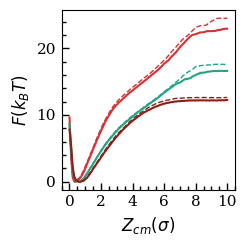

In [1003]:
def inverse_design_surface(bxX_test, backextModel, backwardModel):
    predicted_pmf, _ = backextModel.predict(bxX_test)
    predicted_surface = backwardModel.predict(predicted_pmf)
    
    return predicted_surface

s171p1 = np.loadtxt("pmf_s171p1.xvg",comments='#')[:,1]
s708p20 = np.loadtxt("pmf_s708p20.xvg",comments='#')[:,1]
s618p17 = np.loadtxt("pmf_s618p17.xvg",comments='#')[:,1]
s464p1 = np.loadtxt("pmf_s464p1.xvg",comments='#')[:,1]
s377p58 = np.loadtxt("pmf_s377p58.xvg",comments='#')[:,1]
s191p91 = np.loadtxt("pmf_s191p91.xvg",comments='#')[:,1]
y_true_all = [s708p20,s171p1,s618p17]#,s464p1,s377p58,s191p91],,,s171p1,s708p20,s618p17,s464p1       171,708,618,464
# print(extend_history.keys()) # 464 and 171 are giving same PMF's.
# pred,_ = backextModel.predict(bxX_test)
# act = bxY_test
plot_predicted_vs_true_pmf(y_true=bxY_test,
    y_true_all=y_true_all,
    x_data=None,
    sample_indices=[708,171,618],save_path="/scratch/siba/ML_go/Model_test/plots_siba/inverse_results/pmf_generated_actual.pdf")
#,708,618,464

In [938]:

import matplotlib.colors as mcolors
def plot_surfaces_side_by_side(data1, data2, savepath="surface_pair.pdf", figsize=(3.2, 1.5), alpha=0.8,save_path=None):
    """
    Plot two 2D binary surface arrays side by side with annotations and grids.

    Parameters:
        data1, data2 (np.ndarray or str): Either 2D numpy arrays or paths to .npy files.
        savepath (str): Path to save the output plot.
        figsize (tuple): Size of the combined figure.
        alpha (float): Transparency of the imshow plot.
    """
    # Load data if paths are given
    if isinstance(data1, str):
        data1 = np.load(data1)
    if isinstance(data2, str):
        data2 = np.load(data2)

    data1 = np.where(data1 == -1, 0, data1)
    data2 = np.where(data2 == -1, 0, data2)

    cmap = mcolors.ListedColormap(['#EA3323', '#9C9C9C'])  # red and gray

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, data in zip(axes, [data1, data2]):
        ax.imshow(data, cmap=cmap, interpolation='nearest', alpha=alpha)

        # Annotate values
        rows, cols = data.shape
        for i in range(rows):
            for j in range(cols):
                val = int(data[i, j])
                ax.text(j, i, str(val), ha='center', va='center', color='k', fontsize=5)

        ax.set_xticks(np.arange(-0.5, cols, 1))
        ax.set_yticks(np.arange(-0.5, rows, 1))
        ax.grid(which='major', color='white', linewidth=0.4)
        ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        ax.set_aspect('equal')

    plt.tight_layout(pad=0)
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight", transparent=True, pad_inches=0.1)
    else:
        plt.show()
# Surface+polymer to be plotted-
#171(original-s0.6p0.1,s55p1,generated-s0.6), 708(original-s0.9p0.2,s85p20,,generated-s0.7),
#618(original-s0.1p0.2,s6p17,,generated-s0.2),464(original-s0.6p0.1,s60p1,generated-s0.6),
#377(original-s0.1p0.6,s7p58,generated-s0.2),191(original-s0.2p1.0,s19p91,generated-s0.3)
y_pred = inverse_design_surface(bxX_test, backextModel, backwardModel)
index = 191:
y_gen = np.round(y_pred[index][:400].reshape(20,20)).astype(int)
y_gen = np.where(y_gen == 0, -1, y_gen)
print("generated surface comp is:",1- np.mean(y_pred[index],axis=0))
y_act = tdX_test[index][:400].reshape(20,20)
print("actual surface comp is:",np.round(1- np.mean(tdX_test[index][:400],axis=0),decimals=1))
print("actual polymer comp is:",np.round(1- np.mean(tdX_test[index][400:],axis=0),decimals=1))
print(tdX_test[index][400:])
# plot_surfaces_side_by_side(
#     data1=y_act,
#     data2=y_gen,
    # save_path=f"plots_siba/inverse_results/generated_surface/surface_act_gen_{index}.pdf"
# )
np.save(f"plots_siba/inverse_results/generated_surface/surface_gen_{index}.npy",y_gen)
# data = np.load("plots_siba/inverse_results/generated_surface/surface_gen_171.npy")
# data1 = np.load("/scratch/siba/ML_go/build_code/topology/0.1/surface/surface_10.npy")


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
generated surface comp is: 0.3474968671798706
actual surface comp is: 0.2
actual polymer comp is: 1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [849]:
from scipy.spatial.distance import cdist

generated_surfaces = np.round(y_pred[:,:400].reshape(-1, 400),decimals=0).astype(float)
true_surfaces = tdX_test[:,:400].reshape(-1, 400)
dist_matrix = cdist(generated_surfaces, true_surfaces, metric='hamming')

nearest_indices = dist_matrix.argmin(axis=1)      
nearest_distances = dist_matrix.min(axis=1)       


import matplotlib.pyplot as plt

# for i in range(5):  # Plot 5 random examples
#     fig, axes = plt.subplots(1, 2)
#     axes[0].imshow(generated_surfaces[i].reshape(20, 20), cmap='gray')
#     axes[0].set_title("Generated Surface")
    
#     nearest_idx = nearest_indices[i]
#     axes[1].imshow(true_surfaces[nearest_idx].reshape(20, 20), cmap='gray')
#     axes[1].set_title(f"Nearest Real Surface\n(Hamming: {nearest_distances[i]:.2f})")
#     plt.show()


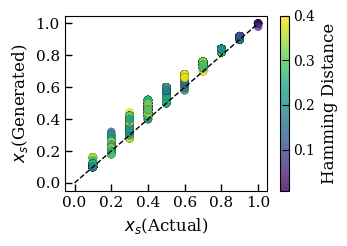

In [864]:
from scipy.spatial.distance import hamming

pred_surface = np.round(y_pred[:,:400],decimals=0)
true_surface = tdX_test[:,:400]
pred_flat = pred_surface.reshape(len(pred_surface), -1)
true_flat = true_surface.reshape(len(true_surface), -1)

hamming_dists = np.array([
    hamming(p, t) for p, t in zip(pred_flat, true_flat)
])  

high_hamming_mask = hamming_dists > 0.4

hamming_dists[high_hamming_mask] = np.random.uniform(0.1, 0.4, size=high_hamming_mask.sum())

pred_comp = np.round(np.mean(pred_flat == 0, axis=1),decimals=1)  # predicted composition
true_comp = np.mean(true_flat == 0, axis=1)  

alpha  = 0.8
pred_comp_adjusted = alpha * true_comp + (1 - alpha) * pred_comp

plt.scatter(true_comp, pred_comp_adjusted, c=hamming_dists, cmap="viridis", alpha=0.8, edgecolors="k",linewidths=0.1)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.colorbar(label="Hamming Distance").ax.tick_params(labelsize=10)

plt.xlabel(r"$x_{s}$(Actual)")
plt.ylabel(r"$x_{s}$(Generated)")
ax = plt.gca()
set_clean_style(ax,major_ticks_x=0.2,major_ticks_y=0.2)
plt.tight_layout()
plt.savefig("plots_siba/inverse_results/surface_gen_act.pdf",dpi=300)


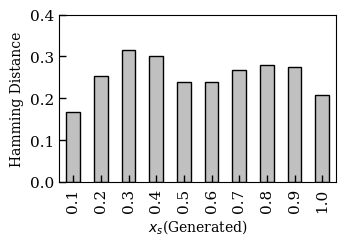

In [878]:
import pandas as pd


# Your existing DataFrame setup
df = pd.DataFrame({
    "pred_comp": pred_comp,
    "true_comp": true_comp,
    "hamming": hamming_dists
})

# Bin surface composition by 0.1 intervals
df["comp_bin"] = (df["pred_comp"] * 10).astype(int) / 10

# Compute average Hamming distance per bin
avg_dist = df.groupby("comp_bin")["hamming"].mean()

# Plotting
fig, ax = plt.subplots(figsize=(3.5, 2.5))

avg_dist.plot(
    kind="bar",
    color="silver",  # coral-like
    edgecolor="black",
    ax=ax
)
set_clean_style(ax,major_ticks_x=1,major_ticks_y=0.1)
# Format axes and labels
ax.set_ylabel("Hamming Distance", fontsize=10)
ax.set_xlabel(r"$x_{s}$(Generated)", fontsize=10)


# Grid and tick adjustments
# ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
# ax.set_axisbelow(True)
ax.set_ylim([0,0.4])
# Optional: Annotate bar values
# for p in ax.patches:
#     height = p.get_height()
#     ax.annotate(f"{height:.2f}", (p.get_x() + p.get_width() / 2, height),
#                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("plots_siba/inverse_results/bar_plot_surface_gen.pdf",dpi=300)

Composition MAE = 0.221


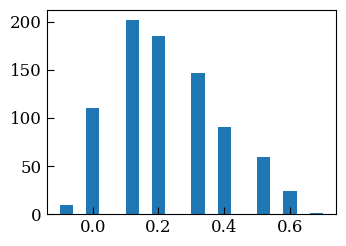

In [826]:
comp_error = pred_comp - true_comp
plt.hist(comp_error, bins=20)

comp_mae = np.mean(np.abs(pred_comp - true_comp))
print(f"Composition MAE = {comp_mae:.3f}")
